# **Análisis Exploratorio de Datos (EDA)**

## *Carga de paquetes y configuración*

In [253]:
suppressPackageStartupMessages({
  library(tidyverse)
  library(gt)
  library(effectsize)   
})

# Parche para que las tablas gt se vean en Jupyter
repr_html.gt_tbl <- function(obj, ...) gt::as_raw_html(obj)
repr_markdown.gt_tbl <- function(obj, ...) NULL
repr_latex.gt_tbl <- function(obj, ...) NULL
for (g in c("repr_html", "repr_markdown", "repr_latex")) {
  registerS3method(g, "gt_tbl", get(paste0(g, ".gt_tbl")), envir = asNamespace("repr"))
}


col_morado <- viridisLite::viridis(10, end = 0.8)[1]
col_verde  <- viridisLite::viridis(10, end = 0.8)[10]

theme_set(theme_minimal(base_size = 12) +
            theme(plot.title = element_text(hjust = 0.5),
                  plot.subtitle = element_text(hjust = 0.5)))


apoyo_vars <- c("Family", "Friends", "SigOthers")

### *Carga de datos*

In [254]:
if (file.exists("../.Renviron")) readRenviron("../.Renviron")
DATA_PATH <- file.path("..", Sys.getenv("DATA_PATH", unset = "data/df_moderation_2026.csv"))

df <- read_csv(DATA_PATH, show_col_types = FALSE)

glimpse(df)

Rows: 680
Columns: 12
$ Gender        <chr> "Female", "Female", "Female", "Female", "Female", "Femal…
$ Age           <dbl> 15, 15, 15, 15, 17, 15, 17, 15, 17, 15, 15, 15, 16, 16, …
$ Ethnicity     <chr> "Afrodescendant", "Mestizo", "Mestizo", NA, "Afrodescend…
$ Grade         <dbl> 9, 9, 9, 9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, …
$ SSE           <chr> "Low", NA, NA, NA, "Low", "Low", "Low", "Low", "Low", "L…
$ Education     <chr> "High School", "High School", "High School", "High Schoo…
$ Municipality  <chr> "Polo Nuevo", "Polo Nuevo", "Polo Nuevo", "Polo Nuevo", …
$ Family        <dbl> -1.52555119, 0.47260174, 0.65589211, -1.08496449, 0.9546…
$ Friends       <dbl> -1.4278704, 0.3525064, 0.3169250, -0.7116390, 1.2053372,…
$ SigOthers     <dbl> -1.0856793, 0.3935668, 0.3133314, -0.7474170, 0.8657182,…
$ Entrapment    <dbl> 1.03400222, -0.85269867, -0.85269867, -0.54487932, -0.22…
$ Entrapment_SE <dbl> 0.3209509, 0.4673559, 0.4673559, 0.3491078, 0.3074096, 0…


En nuestra base datos se encuentran 680 filas x 12 columnas 

## *Diccionario de los datos*

El diccionario de variables es un paso fundamental en cualquier análisis exploratorio, ya que documenta de forma clara y estructurada el significado, tipo estadístico y valores posibles de cada variable del dataset.

In [255]:
# Diccionario de variables
variable_info <- tribble(
  ~Variable,        ~Tipo,                        ~Escala,               ~Descripción,
  "Gender",         "Binaria (moderador)",        "Female / Male",       "Género del estudiante",
  "Age",            "Continua",                   "13 – 20 años",        "Edad en años cumplidos",
  "Ethnicity",      "Nominal (4 niveles)",        "Mestizo / Caucasian / Afrodescendant / Other", "Autoidentificación étnica (Asiático, Indígena y Otro consolidados en Other)",
  "Grade",          "Ordinal (3 niveles)",        "9 / 10 / 11",         "Grado escolar cursado",
  "SSE",            "Ordinal (3 niveles)",        "Low / Medium / High", "Nivel socioeconómico (6 estratos DANE colapsados en 3)",
  "Education",      "Ordinal (4 niveles)",        "Primary / High School / Undergraduate / Graduate", "Máximo nivel educativo alcanzado por los padres o cuidadores",
  "Municipality",   "Nominal (4 niveles)",        "Polo Nuevo / Santo Tomas / Puerto Colombia / Suan", "Municipio al que pertenece el colegio",
  "Family",         "Continua (puntaje latente)", "-2.41 – 1.58",        "Apoyo social percibido de la familia (MSPSS). Mayor valor = más apoyo",
  "Friends",        "Continua (puntaje latente)", "-2.03 – 1.47",        "Apoyo social percibido de los amigos (MSPSS). Mayor valor = más apoyo",
  "SigOthers",      "Continua (puntaje latente)", "-3.11 – 1.59",        "Apoyo social percibido de otras personas significativas (MSPSS). Mayor valor = más apoyo",
  "Entrapment",     "Continua (objetivo)",        "-1.69 – 2.01",        "Puntaje latente de entrapment (sensación de estar atrapado). Mayor valor = más entrapment",
  "Entrapment_SE",  "Continua",                   "0.28 – 0.65",         "Error estándar del puntaje de entrapment (incertidumbre de la medición)"
)

variable_info %>%
  gt() %>%
  tab_header(title = "Diccionario de variables")

<div id="vgxfibpgbh" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#vgxfibpgbh table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#vgxfibpgbh thead, #vgxfibpgbh tbody, #vgxfibpgbh tfoot, #vgxfibpgbh tr, #vgxfibpgbh td, #vgxfibpgbh th {
  border-style: none;
}

#vgxfibpgbh p {
  margin: 0;
  padding: 0;
}

#vgxfibpgbh .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#vgxfibpgbh .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#vgxfibpgbh .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#vgxfibpgbh .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#vgxfibpgbh .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#vgxfibpgbh .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#vgxfibpgbh .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#vgxfibpgbh .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#vgxfibpgbh .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#vgxfibpgbh .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#vgxfibpgbh .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#vgxfibpgbh .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#vgxfibpgbh .gt_spanner_row {
  border-bottom-style: hidden;
}

#vgxfibpgbh .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

## *Datos faltantes por variable*

Antes de examinar cada variable individualmente, se resume la proporción de valores faltantes por columna sobre el total de la muestra (N = 680).

In [256]:
missing_summary <- df %>%
  summarise(across(everything(), ~ sum(is.na(.) | . == ""))) %>%
  pivot_longer(everything(), names_to = "Variable", values_to = "n_missing") %>%
  mutate(pct_missing = round(100 * n_missing / nrow(df), 2)) %>%
  arrange(desc(n_missing))

missing_summary %>%
  gt() %>%
  tab_header(title = "Datos faltantes por variable")

<div id="vtulkwyyec" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#vtulkwyyec table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#vtulkwyyec thead, #vtulkwyyec tbody, #vtulkwyyec tfoot, #vtulkwyyec tr, #vtulkwyyec td, #vtulkwyyec th {
  border-style: none;
}

#vtulkwyyec p {
  margin: 0;
  padding: 0;
}

#vtulkwyyec .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#vtulkwyyec .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#vtulkwyyec .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#vtulkwyyec .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#vtulkwyyec .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#vtulkwyyec .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#vtulkwyyec .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#vtulkwyyec .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#vtulkwyyec .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#vtulkwyyec .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#vtulkwyyec .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#vtulkwyyec .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#vtulkwyyec .gt_spanner_row {
  border-bottom-style: hidden;
}

#vtulkwyyec .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

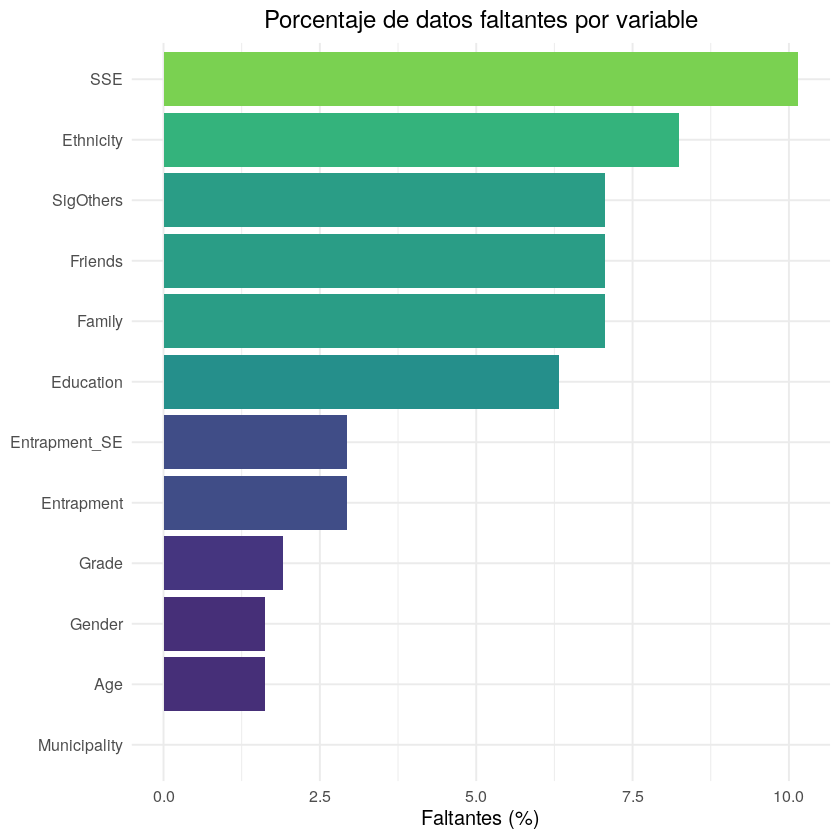

In [257]:
ggplot(missing_summary, aes(x = fct_reorder(Variable, pct_missing), y = pct_missing,
                            fill = pct_missing)) +
  geom_col(show.legend = FALSE) +
  scale_fill_viridis_c(end = 0.8) +
  coord_flip() +
  labs(title = "Porcentaje de datos faltantes por variable",
       x = NULL, y = "Faltantes (%)")

La tabla muestra que ninguna variable supera el 10% de datos faltantes: SSE es la más incompleta (10.15%), seguida de Ethnicity (8.24%), las tres dimensiones de apoyo social (7.06% cada una) y Education (6.32%), mientras que Entrapment tiene 2.94% y Grade, Gender y Age entre 1.6% y 1.9%; Municipality no tiene faltantes. 

### *Patrón de los datos faltantes*
Además del porcentaje por variable, se verifica si los faltantes del apoyo social corresponden a los mismos estudiantes, cuántos casos completos quedan para un modelo con las variables clave y si la falta de datos difiere según el género.

In [258]:
faltantes_apoyo <- rowSums(is.na(df[apoyo_vars]))

tibble(
  Indicador = c("Estudiantes con alguna dimensión de apoyo faltante",
                "Estudiantes con las tres dimensiones de apoyo faltantes",
                "Casos completos (entrapment, apoyo, género, edad, SSE y municipio)"),
  n = c(sum(faltantes_apoyo > 0),
        sum(faltantes_apoyo == 3),
        sum(complete.cases(df[c("Entrapment", apoyo_vars, "Gender", "Age", "SSE", "Municipality")])))
) %>%
  mutate(pct = round(100 * n / nrow(df), 1)) %>%
  gt() %>%
  tab_header(title = "Patrón de datos faltantes")

<div id="woafjyinpz" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#woafjyinpz table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#woafjyinpz thead, #woafjyinpz tbody, #woafjyinpz tfoot, #woafjyinpz tr, #woafjyinpz td, #woafjyinpz th {
  border-style: none;
}

#woafjyinpz p {
  margin: 0;
  padding: 0;
}

#woafjyinpz .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#woafjyinpz .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#woafjyinpz .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#woafjyinpz .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#woafjyinpz .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#woafjyinpz .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#woafjyinpz .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#woafjyinpz .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#woafjyinpz .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#woafjyinpz .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#woafjyinpz .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#woafjyinpz .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#woafjyinpz .gt_spanner_row {
  border-bottom-style: hidden;
}

#woafjyinpz .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

Los 48 estudiantes con apoyo social faltante son los mismos en las tres dimensiones (7.1%): no respondieron la escala completa. Con los casos completos para un modelo con las variables clave quedarían 556 estudiantes (81.8%).

In [259]:
df %>%
  mutate(falta_apoyo = faltantes_apoyo > 0,
         falta_entrapment = is.na(Entrapment)) %>%
  group_by(Gender) %>%
  summarise(n = n(),
            pct_falta_apoyo = round(100 * mean(falta_apoyo), 1),
            pct_falta_entrapment = round(100 * mean(falta_entrapment), 1),
            .groups = "drop") %>%
  gt() %>%
  tab_header(title = "Datos faltantes según género")

<div id="fazezyynsc" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#fazezyynsc table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#fazezyynsc thead, #fazezyynsc tbody, #fazezyynsc tfoot, #fazezyynsc tr, #fazezyynsc td, #fazezyynsc th {
  border-style: none;
}

#fazezyynsc p {
  margin: 0;
  padding: 0;
}

#fazezyynsc .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#fazezyynsc .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#fazezyynsc .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#fazezyynsc .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#fazezyynsc .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#fazezyynsc .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#fazezyynsc .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#fazezyynsc .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#fazezyynsc .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#fazezyynsc .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#fazezyynsc .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#fazezyynsc .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#fazezyynsc .gt_spanner_row {
  border-bottom-style: hidden;
}

#fazezyynsc .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

Datos faltantes según género. Mujeres y hombres tienen los mismos porcentajes de faltantes (6.7% en apoyo y 1.3% en entrapment), sin señal de diferencias por género. Los 11 estudiantes sin dato de género carecen todos de entrapment.

## *Función auxiliar de frecuencias*

Se define una función auxiliar para generar, de forma consistente, las tablas de frecuencia y los gráficos de barras (conteo + porcentaje) de las covariables categóricas.

In [260]:
freq_table <- function(data, var, levels_order = NULL) {
  x <- data[[var]]
  x_chr <- as.character(x)
  x_chr[is.na(x_chr) | x_chr == ""] <- "Missing"

  if (is.null(levels_order)) {
    lv <- c(sort(unique(x_chr[x_chr != "Missing"])), "Missing")
  } else {
    lv <- c(levels_order, "Missing")
  }

  tibble(Category = factor(x_chr, levels = lv)) %>%
    count(Category, .drop = FALSE, name = "n") %>%
    mutate(pct = round(100 * n / sum(n), 2))
}

plot_freq <- function(tbl, title, xlab) {
  ggplot(tbl, aes(x = Category, y = pct, fill = Category)) +
    geom_col(show.legend = FALSE) +
    geom_text(aes(label = n), vjust = -0.4, fontface = "bold") +
    scale_fill_viridis_d(end = 0.8) +
    scale_y_continuous(limits = c(0, 100)) +
    labs(title = title, x = xlab, y = "Participantes (%)")
}


# *Analisis univariado*

## *Género*

Distribución de la muestra por género (`Female`, `Male`), con los casos sin
respuesta agrupados como `Missing`.

In [261]:
gender_tbl <- freq_table(df, "Gender", levels_order = c("Female", "Male"))
gender_tbl %>% gt() %>% tab_header(title = "Género")

<div id="svfapsuczs" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#svfapsuczs table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#svfapsuczs thead, #svfapsuczs tbody, #svfapsuczs tfoot, #svfapsuczs tr, #svfapsuczs td, #svfapsuczs th {
  border-style: none;
}

#svfapsuczs p {
  margin: 0;
  padding: 0;
}

#svfapsuczs .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#svfapsuczs .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#svfapsuczs .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#svfapsuczs .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#svfapsuczs .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#svfapsuczs .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#svfapsuczs .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#svfapsuczs .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#svfapsuczs .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#svfapsuczs .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#svfapsuczs .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#svfapsuczs .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#svfapsuczs .gt_spanner_row {
  border-bottom-style: hidden;
}

#svfapsuczs .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

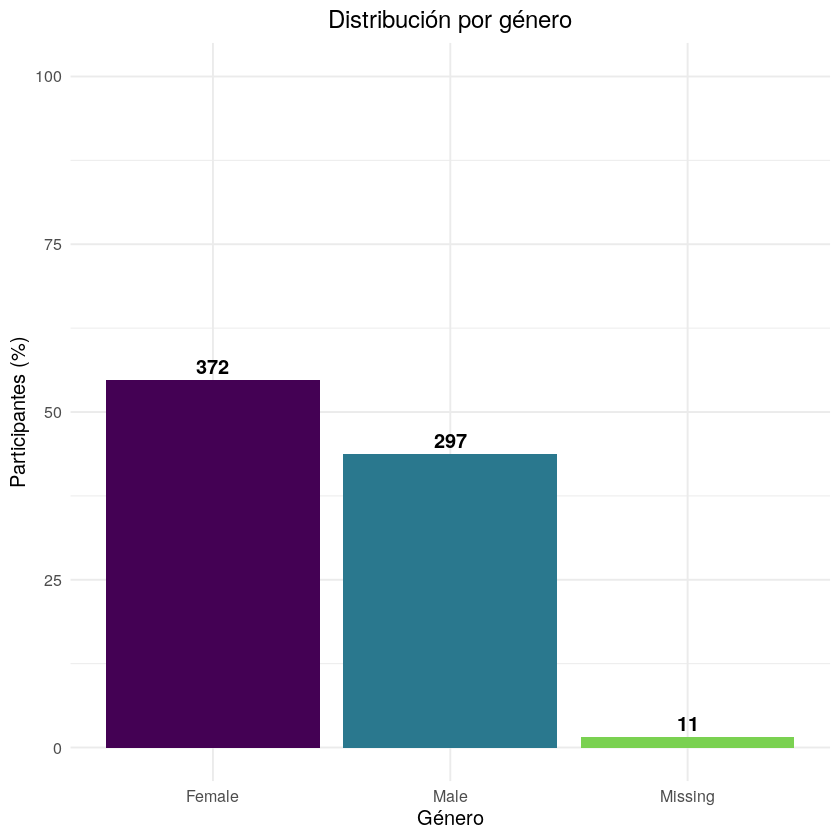

In [262]:
plot_freq(gender_tbl, "Distribución por género", "Género")

La muestra tiene 372 mujeres (54.7%), 297 hombres (43.7%) y 11 casos sin dato (1.6%). Hay una leve mayoría femenina, pero los dos grupos son lo bastante grandes y equilibrados para estimar sin problema una interacción entre género y apoyo social; no hay riesgo de un grupo demasiado pequeño.

## *Edad*

`Age` fue recolectada como campo numérico abierto. Se examina la completitud, la distribución (histograma y boxplot) y la presencia de valores atípicos mediante un filtro de Hampel ($\text{mediana} \pm 3 \times \text{MAD}$).

In [263]:
hampel_bounds <- function(x, k = 3) {
  x <- x[!is.na(x)]
  med <- median(x)
  mad_x <- mad(x, constant = 1.4826)
  c(lower = med - k * mad_x, upper = med + k * mad_x)
}

age_complete <- sum(!is.na(df$Age))
age_missing <- sum(is.na(df$Age))

cat(sprintf("Edad: %d completos, %d faltantes (%.2f%%)\n",
            age_complete, age_missing, 100 * age_missing / nrow(df)))

summary(df$Age)

Edad: 669 completos, 11 faltantes (1.62%)


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
  13.00   15.00   16.00   15.95   17.00   20.00      11 

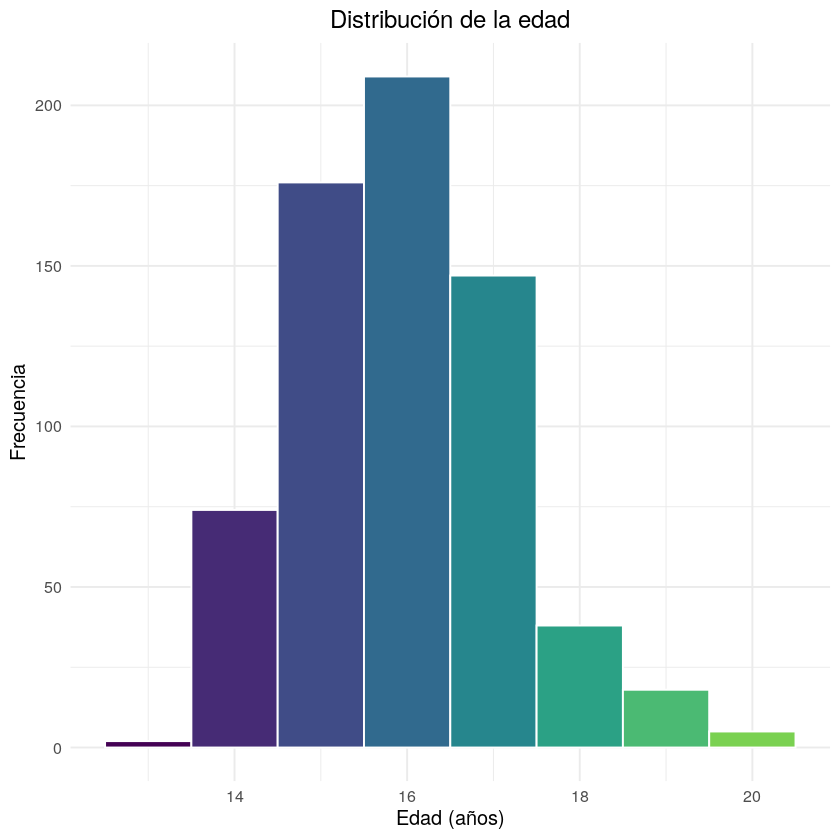

In [264]:
ggplot(df, aes(x = Age)) +
  geom_histogram(aes(fill = after_stat(x)), binwidth = 1, color = "white",
                 na.rm = TRUE, show.legend = FALSE) +
  scale_fill_viridis_c(end = 0.8) +
  labs(title = "Distribución de la edad", x = "Edad (años)", y = "Frecuencia")

La edad va de 13 a 20 años, con mediana de 16 y media de 15.95, prácticamente iguales, lo que confirma una distribución casi simétrica con leve cola derecha. El 50% central de los estudiantes tiene entre 15 y 17 años (primer y tercer cuartil), un rango estrecho de solo dos años.

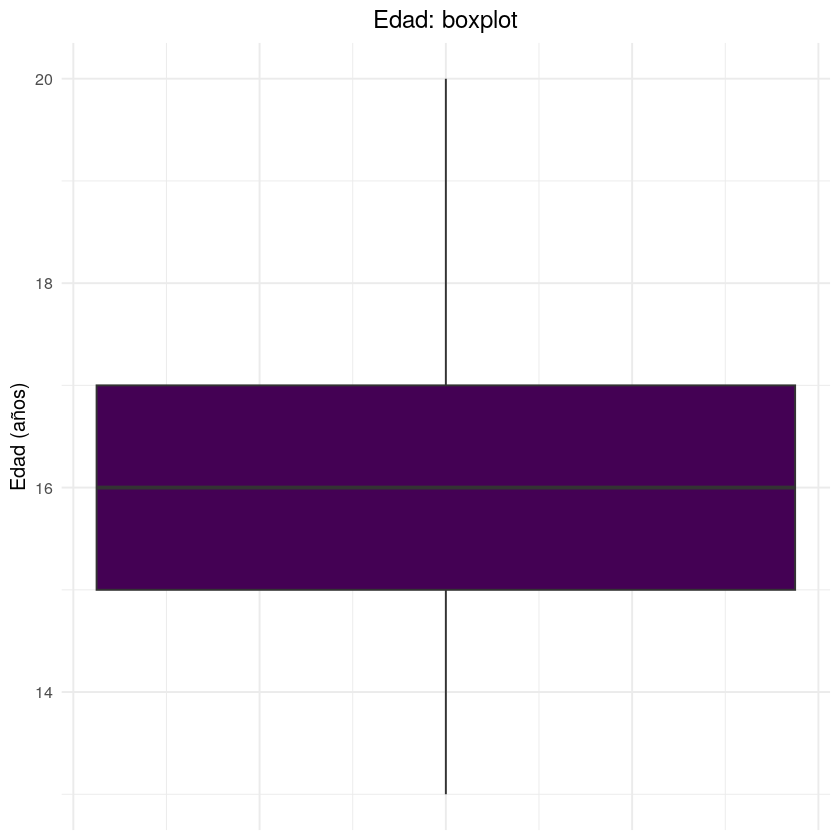

In [265]:
ggplot(df, aes(y = Age)) +
  geom_boxplot(fill = viridisLite::viridis(10, end = 0.8)[1], na.rm = TRUE) +
  labs(title = "Edad: boxplot", y = "Edad (años)", x = NULL) +
  theme(axis.text.x = element_blank(), axis.ticks.x = element_blank())

El boxplot no marca ningún valor atípico, a pesar de que el histograma mostraba una cola derecha con pocos estudiantes de 18 a 20 años.

In [266]:
age_bounds <- hampel_bounds(df$Age)
age_bounds

age_outliers <- df %>% filter(Age < age_bounds["lower"] | Age > age_bounds["upper"])
nrow(age_outliers)

lower   upper 
11.5522 20.4478

[1] 0

Esto significa que no hay estudiantes con edades extremas: ninguna edad se sale de lo razonable respecto al resto de la muestra.

## *Grado escolar*

`Grade` fue estandarizado a los tres niveles de la cohorte: 9.º, 10.º y
11.º grado.

In [267]:
df <- df %>% mutate(Grade = as.character(Grade))

grade_tbl <- freq_table(df, "Grade", levels_order = c("9", "10", "11"))
grade_tbl %>% gt() %>% tab_header(title = "Grado escolar")

<div id="ualogslvom" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#ualogslvom table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#ualogslvom thead, #ualogslvom tbody, #ualogslvom tfoot, #ualogslvom tr, #ualogslvom td, #ualogslvom th {
  border-style: none;
}

#ualogslvom p {
  margin: 0;
  padding: 0;
}

#ualogslvom .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#ualogslvom .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#ualogslvom .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#ualogslvom .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#ualogslvom .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#ualogslvom .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#ualogslvom .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#ualogslvom .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#ualogslvom .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#ualogslvom .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#ualogslvom .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#ualogslvom .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#ualogslvom .gt_spanner_row {
  border-bottom-style: hidden;
}

#ualogslvom .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

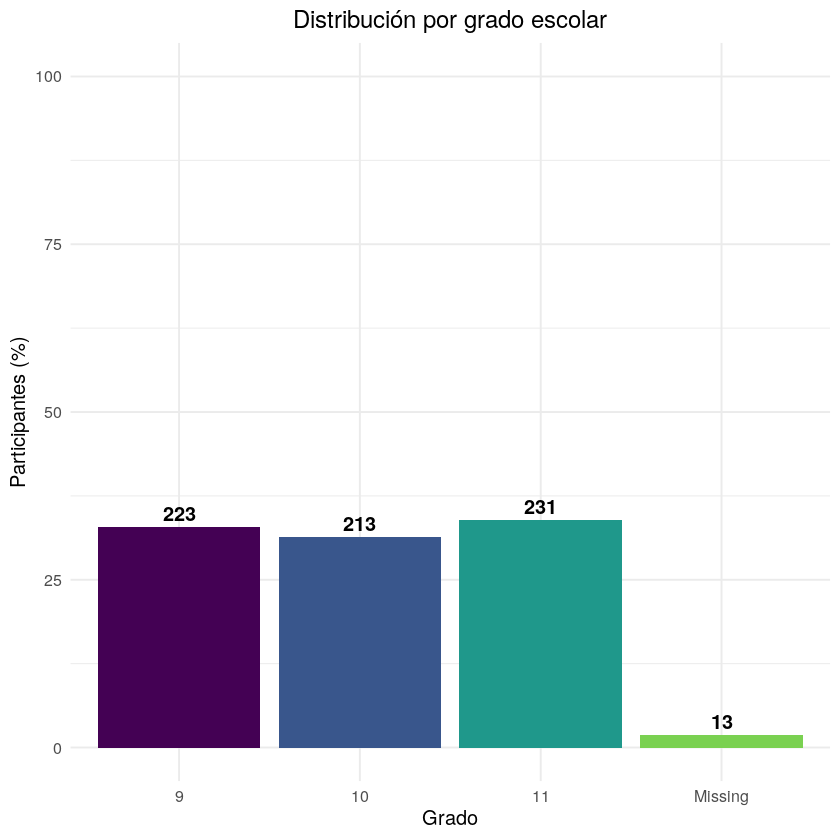

In [268]:
plot_freq(grade_tbl, "Distribución por grado escolar", "Grado")

La muestra está muy equilibrada entre los tres grados: 223 estudiantes en 9.º (32.8%), 213 en 10.º (31.3%) y 231 en 11.º (34.0%), con 13 casos sin dato (1.9%). Esta distribución casi uniforme indica que el muestreo cubrió de forma pareja toda la cohorte y que ningún grado domina, de modo que grado no introduce un desbalance que distorsione los modelos

## *Municipio*

In [269]:
municip_tbl <- freq_table(df, "Municipality",
                           levels_order = c("Polo Nuevo", "Santo Tomas",
                                             "Puerto Colombia", "Suan"))
municip_tbl %>% gt() %>% tab_header(title = "Municipio")

<div id="sknvyqxmfh" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#sknvyqxmfh table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#sknvyqxmfh thead, #sknvyqxmfh tbody, #sknvyqxmfh tfoot, #sknvyqxmfh tr, #sknvyqxmfh td, #sknvyqxmfh th {
  border-style: none;
}

#sknvyqxmfh p {
  margin: 0;
  padding: 0;
}

#sknvyqxmfh .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#sknvyqxmfh .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#sknvyqxmfh .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#sknvyqxmfh .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#sknvyqxmfh .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#sknvyqxmfh .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#sknvyqxmfh .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#sknvyqxmfh .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#sknvyqxmfh .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#sknvyqxmfh .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#sknvyqxmfh .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#sknvyqxmfh .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#sknvyqxmfh .gt_spanner_row {
  border-bottom-style: hidden;
}

#sknvyqxmfh .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

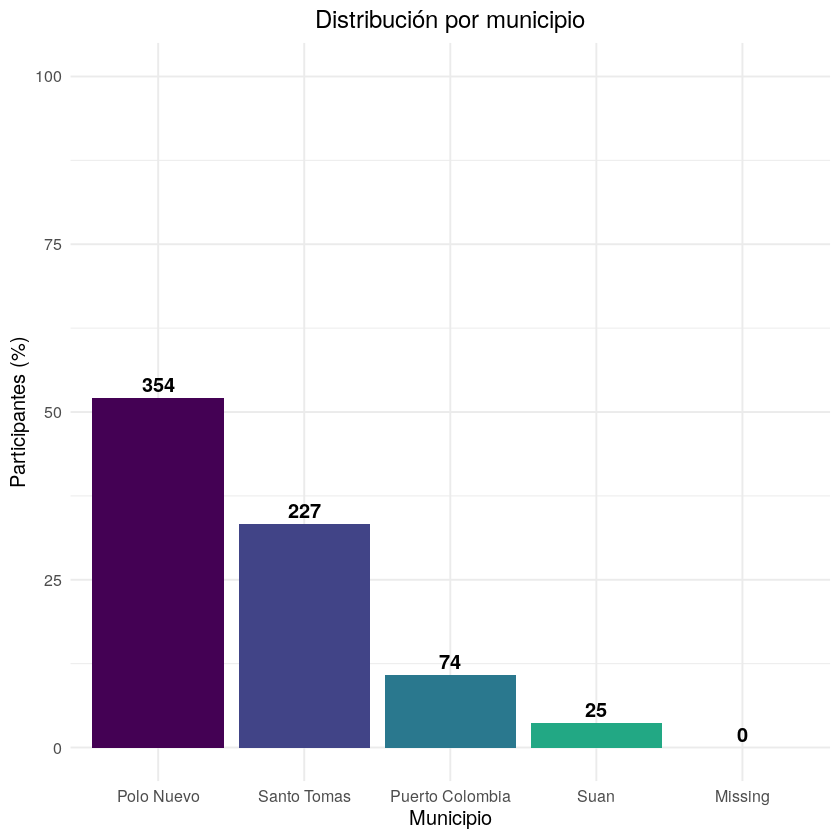

In [270]:
plot_freq(municip_tbl, "Distribución por municipio", "Municipio")

La muestra proviene de cuatro municipios y está muy concentrada: Polo Nuevo aporta 354 estudiantes (52.1%) y Santo Tomás 227 (33.4%), de modo que entre los dos suman casi 86% de los casos, mientras que Puerto Colombia contribuye con 74 (10.9%) y Suan con solo 25 (3.7%).

## *Etnia*

Las categorías de baja frecuencia (Asiático, Indígena, Otro) fueron
consolidadas en un nivel `Other`, preservando la granularidad demográfica de
los tres grupos principales: Mestizo, Caucásico y Afrodescendiente.

In [271]:
ethnicity_tbl <- freq_table(df, "Ethnicity",
                             levels_order = c("Mestizo", "Caucasian",
                                               "Afrodescendant", "Other"))
ethnicity_tbl %>% gt() %>% tab_header(title = "Grupo étnico")

<div id="dnhukskyxr" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#dnhukskyxr table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#dnhukskyxr thead, #dnhukskyxr tbody, #dnhukskyxr tfoot, #dnhukskyxr tr, #dnhukskyxr td, #dnhukskyxr th {
  border-style: none;
}

#dnhukskyxr p {
  margin: 0;
  padding: 0;
}

#dnhukskyxr .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#dnhukskyxr .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#dnhukskyxr .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#dnhukskyxr .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#dnhukskyxr .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#dnhukskyxr .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#dnhukskyxr .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#dnhukskyxr .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#dnhukskyxr .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#dnhukskyxr .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#dnhukskyxr .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#dnhukskyxr .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#dnhukskyxr .gt_spanner_row {
  border-bottom-style: hidden;
}

#dnhukskyxr .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

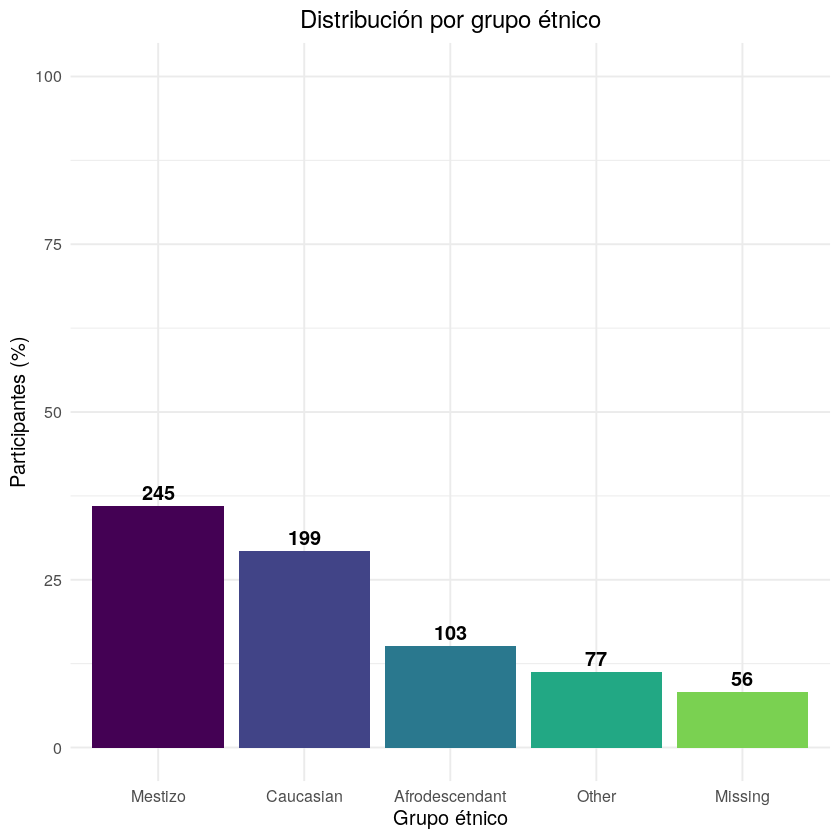

In [272]:
plot_freq(ethnicity_tbl, "Distribución por grupo étnico", "Grupo étnico")

La muestra se reparte entre Mestizo (245; 36.0%), Caucásico (199; 29.3%), Afrodescendiente (103; 15.2%) y Other (77; 11.3%), con 56 casos sin dato (8.2%), el segundo mayor porcentaje de faltantes del conjunto. Como se indica en la nota del notebook, Other agrupa las categorías de baja frecuencia (Asiático, Indígena y Otro) como mencionamos anteriormente.

## *Nivel socioeconómico (SSE)*

Los seis estratos oficiales del DANE fueron colapsados en tres niveles
(`Low`, `Medium`, `High`) para evitar categorías con frecuencias
extremadamente bajas en los estratos superiores.

In [273]:
sse_tbl <- freq_table(df, "SSE", levels_order = c("Low", "Medium", "High"))
sse_tbl %>% gt() %>% tab_header(title = "Nivel socioeconómico")

<div id="lvijaeldmu" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#lvijaeldmu table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#lvijaeldmu thead, #lvijaeldmu tbody, #lvijaeldmu tfoot, #lvijaeldmu tr, #lvijaeldmu td, #lvijaeldmu th {
  border-style: none;
}

#lvijaeldmu p {
  margin: 0;
  padding: 0;
}

#lvijaeldmu .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#lvijaeldmu .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#lvijaeldmu .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#lvijaeldmu .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#lvijaeldmu .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#lvijaeldmu .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#lvijaeldmu .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#lvijaeldmu .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#lvijaeldmu .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#lvijaeldmu .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#lvijaeldmu .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#lvijaeldmu .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#lvijaeldmu .gt_spanner_row {
  border-bottom-style: hidden;
}

#lvijaeldmu .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

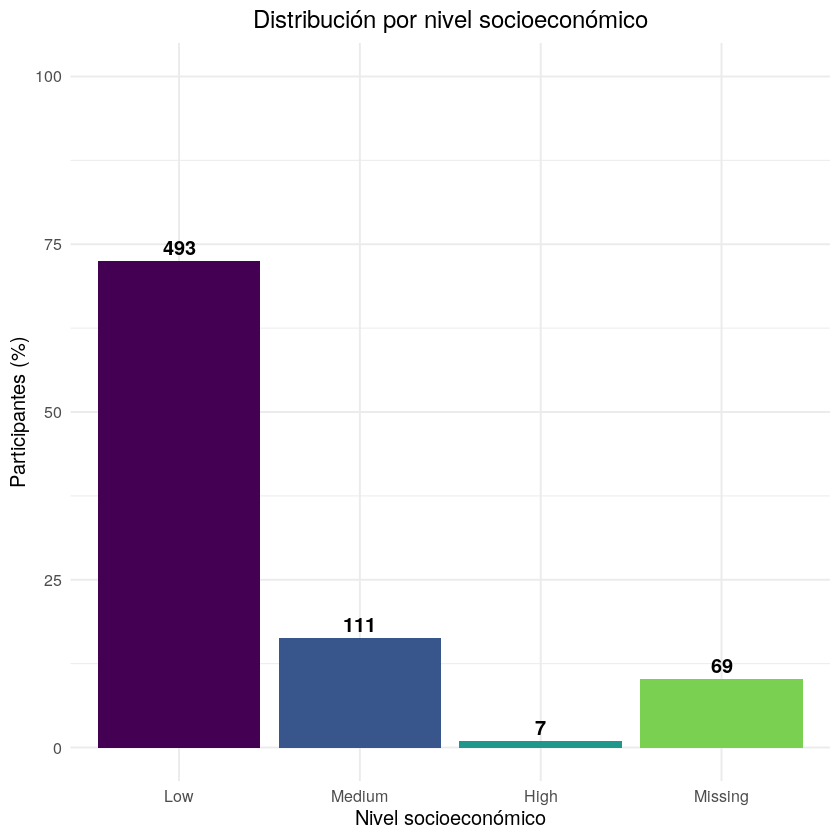

In [274]:
plot_freq(sse_tbl, "Distribución por nivel socioeconómico", "Nivel socioeconómico")

La muestra está claramente concentrada en el nivel bajo: 493 estudiantes (72.5%) pertenecen a Low, 111 (16.3%) a Medium y solo 7 (1.0%) a High, con 69 casos sin dato (10.2%), el mayor porcentaje de faltantes de todas las variables. Esto refleja que el estudio se hizo en colegios de municipios de estratos bajos, lo que limita la variabilidad socioeconómica de la muestra y, por tanto, el poder de esta covariable para explicar diferencias en el entrapment.

### *Nivel educativo de los padres*

El nivel educativo más alto alcanzado por los padres o cuidadores fue
agrupado en cuatro categorías: `Primary`, `High School`, `Undergraduate` y
`Graduate`.

In [275]:
education_tbl <- freq_table(df, "Education",
                             levels_order = c("Primary", "High School",
                                               "Undergraduate", "Graduate"))
education_tbl %>% gt() %>% tab_header(title = "Nivel educativo de los padres")

<div id="smnwszuqou" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#smnwszuqou table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#smnwszuqou thead, #smnwszuqou tbody, #smnwszuqou tfoot, #smnwszuqou tr, #smnwszuqou td, #smnwszuqou th {
  border-style: none;
}

#smnwszuqou p {
  margin: 0;
  padding: 0;
}

#smnwszuqou .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#smnwszuqou .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#smnwszuqou .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#smnwszuqou .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#smnwszuqou .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#smnwszuqou .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#smnwszuqou .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#smnwszuqou .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#smnwszuqou .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#smnwszuqou .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#smnwszuqou .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#smnwszuqou .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#smnwszuqou .gt_spanner_row {
  border-bottom-style: hidden;
}

#smnwszuqou .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

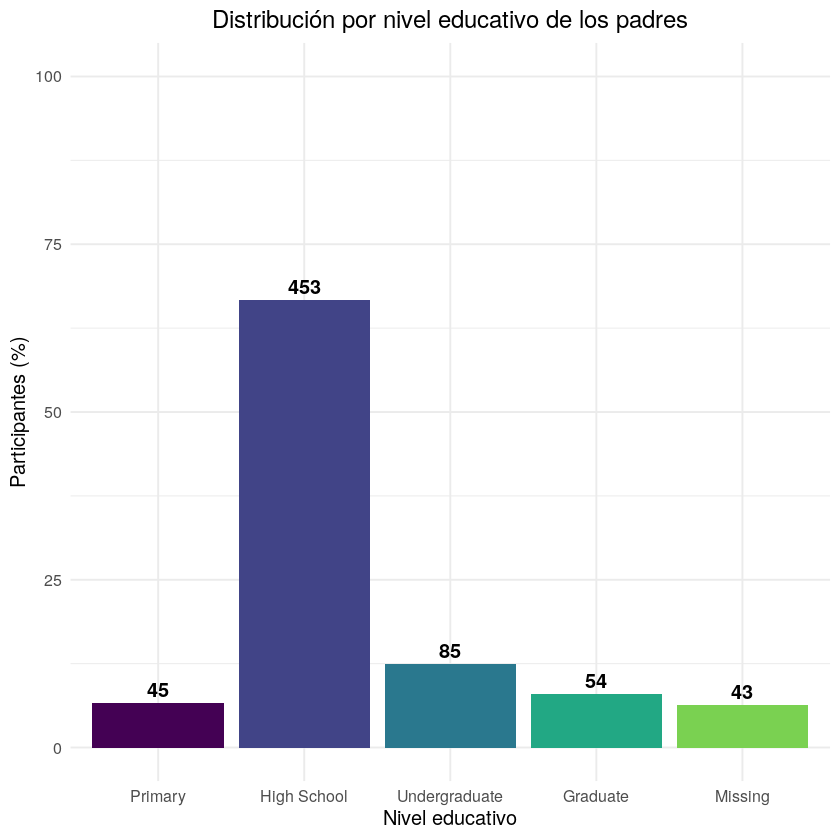

In [276]:
plot_freq(education_tbl, "Distribución por nivel educativo de los padres",
           "Nivel educativo")

La gran mayoría de los estudiantes tiene padres con educación secundaria: High School reúne 453 casos (66.6%), muy por encima de Undergraduate (85; 12.5%), Graduate (54; 7.9%) y Primary (45; 6.6%), con 43 casos sin dato (6.3%).

## *Distribución del apoyo social y del entrapment*

Las columnas `Family`, `Friends` y `SigOthers` corresponden a los puntajes
latentes estimados para las tres dimensiones del MSPSS (familia, amigos y
otras personas significativas), y `Entrapment` / `Entrapment_SE` al puntaje
latente de *entrapment* y su error estándar. Estas son las variables
centrales de los modelos de moderación planteados en los objetivos
específicos del proyecto, por lo que se hara una analisis extenso de estas columnas.

In [277]:
support_vars <- c("Family", "Friends", "SigOthers", "Entrapment", "Entrapment_SE")

support_summary <- df %>%
  select(all_of(support_vars)) %>%
  pivot_longer(everything(), names_to = "Variable", values_to = "value") %>%
  group_by(Variable) %>%
  summarise(
    n = sum(!is.na(value)),
    n_missing = sum(is.na(value)),
    mean = round(mean(value, na.rm = TRUE), 3),
    sd = round(sd(value, na.rm = TRUE), 3),
    median = round(median(value, na.rm = TRUE), 3),
    IQR = round(IQR(value, na.rm = TRUE), 3),
    min = round(min(value, na.rm = TRUE), 3),
    max = round(max(value, na.rm = TRUE), 3),
    .groups = "drop"
  )

support_summary %>% gt() %>% tab_header(title = "Resumen: apoyo social y entrapment")

<div id="hqhggxfrvf" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#hqhggxfrvf table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#hqhggxfrvf thead, #hqhggxfrvf tbody, #hqhggxfrvf tfoot, #hqhggxfrvf tr, #hqhggxfrvf td, #hqhggxfrvf th {
  border-style: none;
}

#hqhggxfrvf p {
  margin: 0;
  padding: 0;
}

#hqhggxfrvf .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#hqhggxfrvf .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#hqhggxfrvf .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#hqhggxfrvf .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#hqhggxfrvf .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#hqhggxfrvf .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#hqhggxfrvf .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#hqhggxfrvf .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#hqhggxfrvf .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#hqhggxfrvf .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#hqhggxfrvf .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#hqhggxfrvf .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#hqhggxfrvf .gt_spanner_row {
  border-bottom-style: hidden;
}

#hqhggxfrvf .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

In [278]:
hist_latente <- function(var, titulo) {
  df %>%
    filter(!is.na(.data[[var]])) %>%
    ggplot(aes(x = .data[[var]])) +
    geom_histogram(aes(fill = after_stat(x)), bins = 30, color = "white",
                   show.legend = FALSE) +
    scale_fill_viridis_c(end = 0.8) +
    labs(title = titulo, x = "Puntaje (escala estandarizada)", y = "Frecuencia")
}

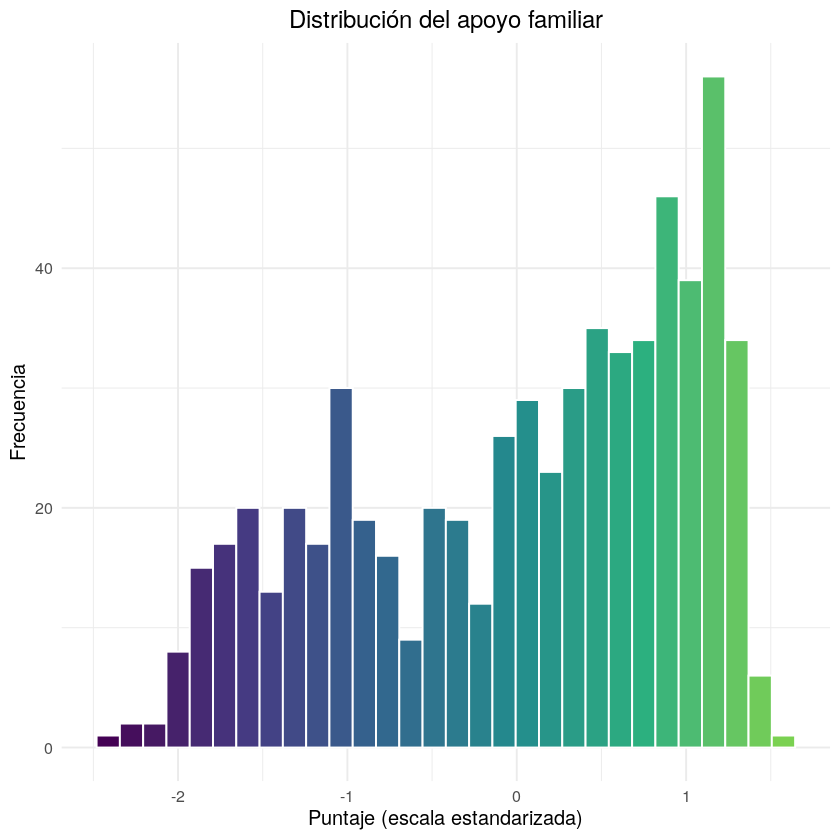

In [279]:
hist_latente("Family", "Distribución del apoyo familiar")

Tiene 632 casos válidos y una distribución asimétrica hacia valores bajos: la mediana (0.254) supera a la media (0.019) y la mayoría de los adolescentes percibe niveles medios a altos de apoyo, con una minoría de puntajes bajos que arrastra la media. La forma es irregular, con más de una concentración de casos.

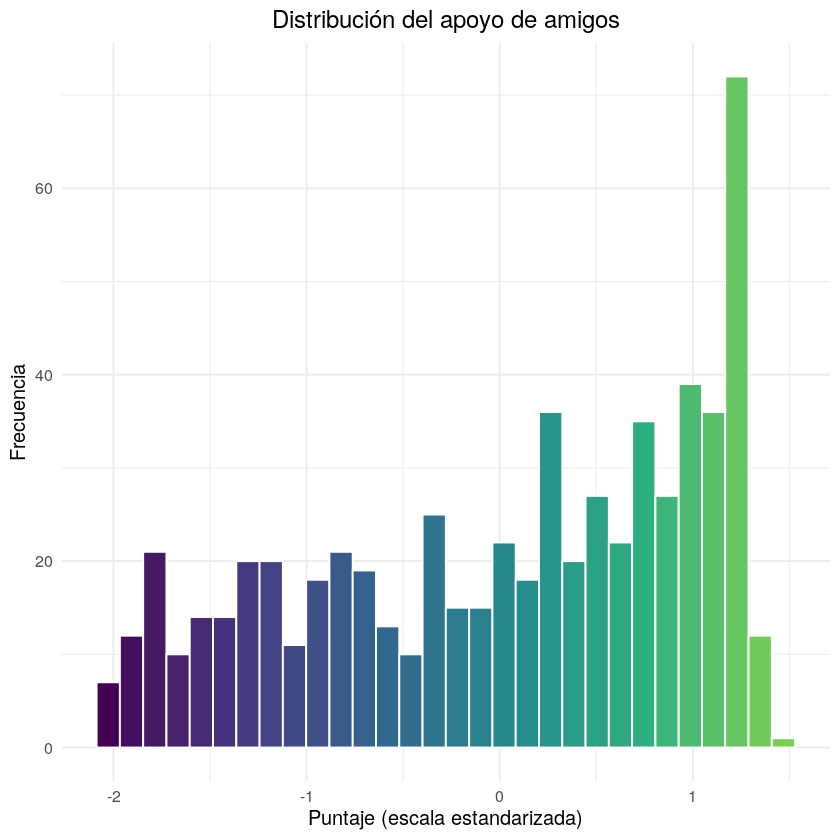

In [280]:
hist_latente("Friends", "Distribución del apoyo de amigos")

También es asimétrica hacia valores bajos (mediana 0.242, media 0.026), pero más plana, con casos repartidos por toda la escala. Destaca un pico en el extremo superior (unos 70 estudiantes), un efecto techo: muchos adolescentes puntúan lo máximo en apoyo de amigos.

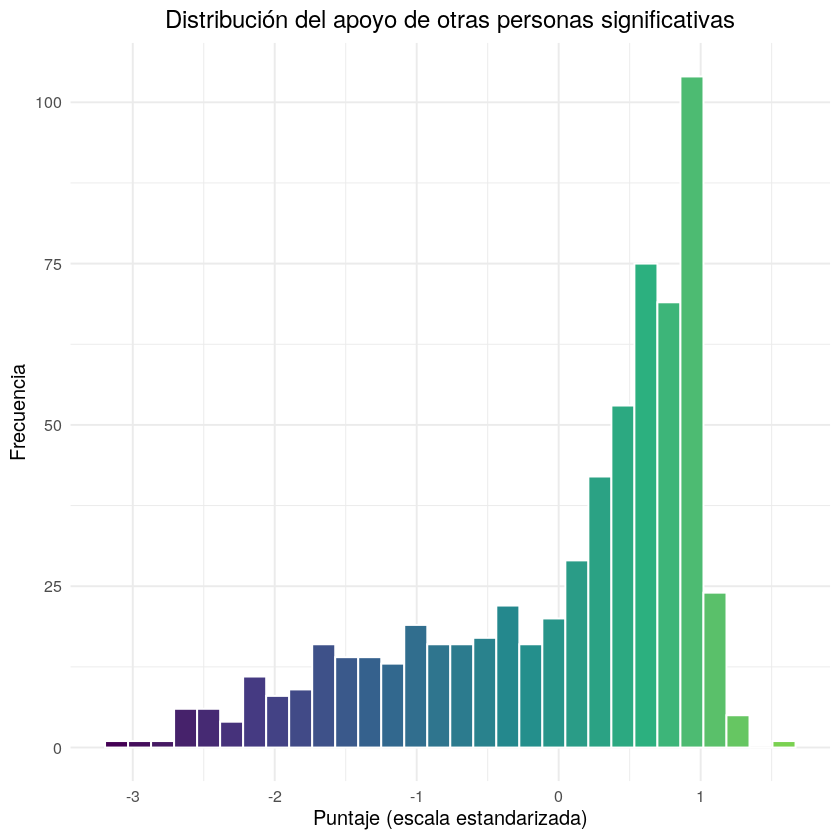

In [281]:
hist_latente("SigOthers", "Distribución del apoyo de otras personas significativas")

Es la más asimétrica: se concentra entre 0 y 1, con un pico de más de 100 estudiantes, y tiene una cola larga hasta -3.1. Presenta efecto techo, y su cola baja explica los 46 casos que marcó el filtro de Hampel, adolescentes con muy poco apoyo que conviene conservar.

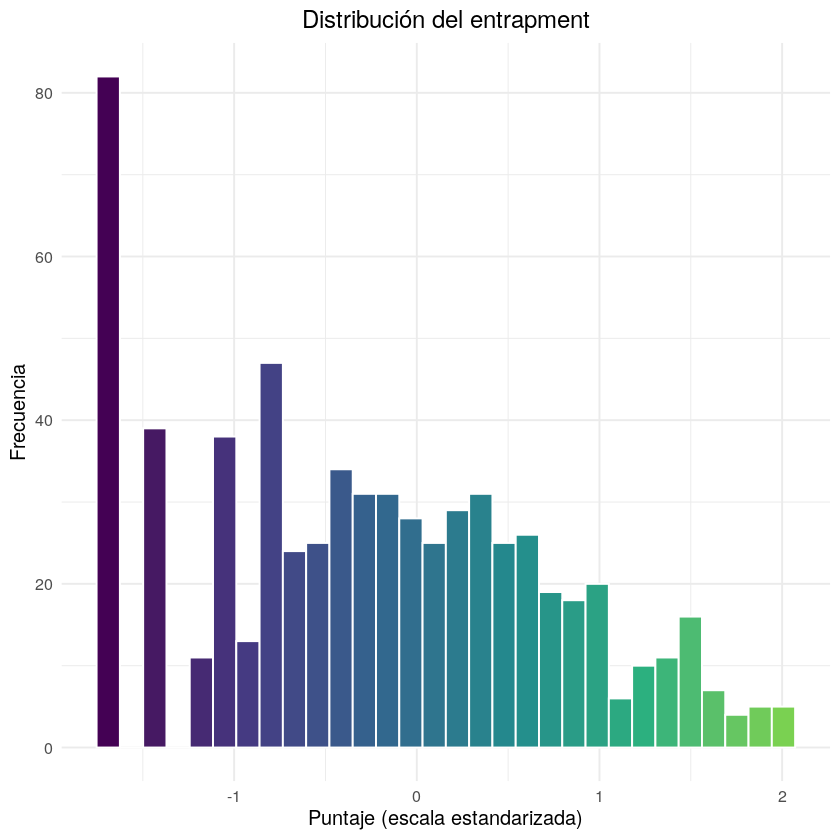

In [282]:
hist_latente("Entrapment", "Distribución del entrapment")

Tiene 660 casos válidos, con media (-0.254) y mediana (-0.281) casi iguales. Destaca una barra muy alta en el mínimo (cerca del 12% de la muestra), un efecto piso de adolescentes que no reportan sentirse atrapados, y desde ahí la frecuencia baja de forma gradual hacia valores altos.

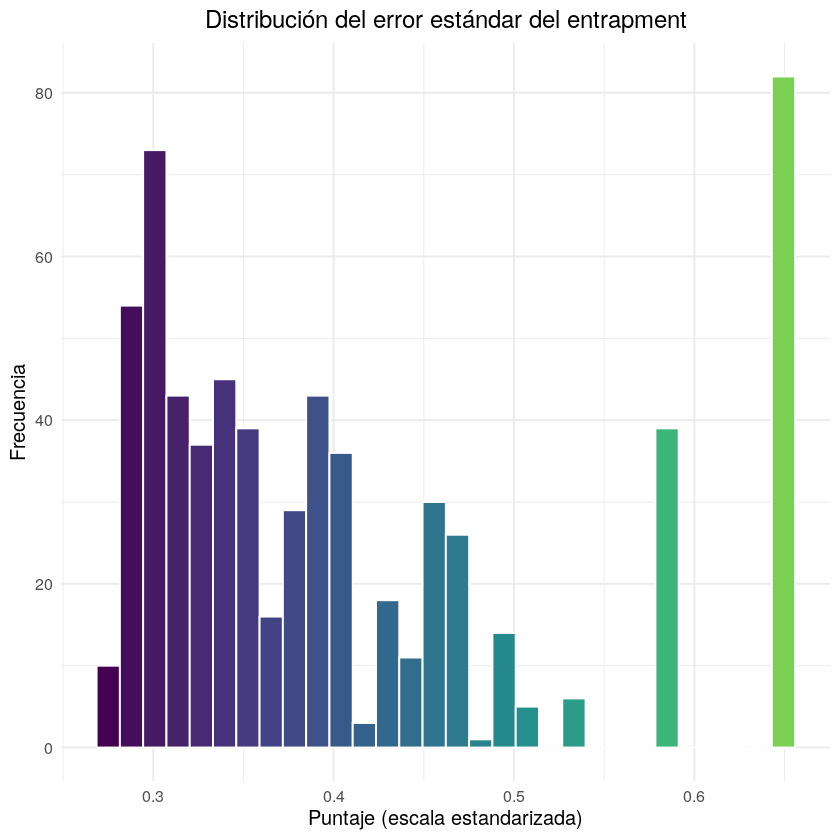

In [283]:
hist_latente("Entrapment_SE", "Distribución del error estándar del entrapment")

Promedia 0.412, un error pequeño frente a la desviación estándar del puntaje (0.967), aunque no despreciable, y justifica incorporarlo en el modelo. Hay una barra alta en el máximo (unos 80 casos): son los mismos adolescentes del piso del entrapment, a quienes el modelo ubica con menos precisión.

### *Valores atípicos (filtro de Hampel)*

Se aplica el mismo criterio de detección de atípicos usado para las
variables antropométricas en el EDA original, sobre cada uno de los
puntajes latentes.

In [284]:
outlier_counts <- map_dfr(c("Family", "Friends", "SigOthers", "Entrapment"), function(v) {
  bounds <- hampel_bounds(df[[v]])
  n_out <- sum(df[[v]] < bounds["lower"] | df[[v]] > bounds["upper"], na.rm = TRUE)
  tibble(Variable = v, lower = bounds["lower"], upper = bounds["upper"], n_outliers = n_out)
})

outlier_counts %>% gt() %>% tab_header(title = "Límites de Hampel y atípicos")

<div id="xgzzojpqgy" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#xgzzojpqgy table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#xgzzojpqgy thead, #xgzzojpqgy tbody, #xgzzojpqgy tfoot, #xgzzojpqgy tr, #xgzzojpqgy td, #xgzzojpqgy th {
  border-style: none;
}

#xgzzojpqgy p {
  margin: 0;
  padding: 0;
}

#xgzzojpqgy .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#xgzzojpqgy .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#xgzzojpqgy .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#xgzzojpqgy .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#xgzzojpqgy .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#xgzzojpqgy .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#xgzzojpqgy .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#xgzzojpqgy .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#xgzzojpqgy .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#xgzzojpqgy .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#xgzzojpqgy .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#xgzzojpqgy .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#xgzzojpqgy .gt_spanner_row {
  border-bottom-style: hidden;
}

#xgzzojpqgy .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

El filtro no detecta atípicos en Family, Friends ni Entrapment, pero marca 46 casos en SigOthers (7.3%), todos en la cola inferior. Esto se debe a que la variable está sesgada hacia valores altos y el filtro asume simetría, por lo que señala como atípicos a adolescentes con muy poco apoyo de personas significativas, justamente los más relevantes para el estudio.

# *Analisis Bivariado*


Para el análisis bivariado se examina la relación entre cada variable predictora y la variable objetivo *entrapment*. Se reportan pruebas paramétricas y no paramétricas lado a lado, junto con su tamaño del efecto, porque el *entrapment* presenta efecto piso y el apoyo social es asimétrico. En las comparaciones por género de las tres dimensiones del apoyo social los valores p se ajustan con el método de Holm; en las demás pruebas se reportan sin ajustar, por tratarse de un análisis exploratorio.

## *Perfil sociodemográfico según género*

Antes de examinar la moderación conviene saber si mujeres y hombres son comparables en las demás variables. Se contrasta el género con municipio, grado, nivel socioeconómico, etnia y nivel educativo de los padres mediante $\chi^2$ (con simulación de Monte Carlo cuando alguna frecuencia esperada es menor que 5), reportando n (%) dentro de cada género, el valor p y la V de Cramér; los casos `Missing` se excluyen de la prueba y se reportan aparte. Para la edad se reporta media (DE), la prueba de Wilcoxon y el tamaño del efecto rango-biserial.

In [310]:
# Balance sociodemográfico entre mujeres y hombres.
# χ² con simulación de Monte Carlo cuando alguna frecuencia esperada es < 5.
set.seed(2026)

niveles_gen <- list(
  Municipality = c("Polo Nuevo", "Santo Tomas", "Puerto Colombia", "Suan"),
  Grade        = c("9", "10", "11"),
  SSE          = c("Low", "Medium", "High"),
  Ethnicity    = c("Mestizo", "Caucasian", "Afrodescendant", "Other"),
  Education    = c("Primary", "High School", "Undergraduate", "Graduate")
)

d_bal <- df %>%
  filter(Gender %in% c("Female", "Male")) %>%
  mutate(Gender = factor(Gender, levels = c("Female", "Male")))

fmt_p <- function(x) ifelse(x < 0.001, "< .001", sprintf("%.3f", x))
solo_primera <- function(x, n) c(x, rep(NA_character_, n - 1))

tabla_gen <- imap_dfr(niveles_gen, function(lv, v) {
  d <- d_bal %>%
    mutate(nivel = as.character(.data[[v]]),
           nivel = ifelse(is.na(nivel) | nivel == "", NA_character_, nivel))

  faltan <- d %>% filter(is.na(nivel)) %>% count(Gender, .drop = FALSE)
  tab <- table(factor(d$nivel[!is.na(d$nivel)], levels = lv), d$Gender[!is.na(d$nivel)])

  mc <- any(suppressWarnings(chisq.test(tab)$expected) < 5)   # ¿alguna esperada < 5?
  ji <- suppressWarnings(chisq.test(tab, simulate.p.value = mc, B = 10000))
  V  <- cramers_v(tab, adjust = FALSE)

  celdas <- as.data.frame.matrix(tab) %>%
    rownames_to_column("Nivel") %>%
    mutate(Female = sprintf("%d (%.1f%%)", Female, 100 * Female / sum(Female)),
           Male   = sprintf("%d (%.1f%%)", Male,   100 * Male   / sum(Male)))
  k <- nrow(celdas)

  tibble(
    Variable = v,
    Nivel = celdas$Nivel, Female = celdas$Female, Male = celdas$Male,
    Prueba  = solo_primera(if (mc) "χ² (Monte Carlo)" else "χ²", k),
    p       = solo_primera(fmt_p(ji$p.value), k),
    Efecto  = solo_primera(sprintf("V = %.3f", V$Cramers_v), k),
    Missing = solo_primera(sprintf("F: %d · M: %d",
                                   faltan$n[faltan$Gender == "Female"],
                                   faltan$n[faltan$Gender == "Male"]), k)
  )
})

# Edad: media (DE), Wilcoxon y r rango-biserial
d_age <- d_bal %>% select(Gender, Age) %>% drop_na()
w_age  <- wilcox.test(Age ~ Gender, data = d_age, exact = FALSE)
rb_age <- rank_biserial(Age ~ Gender, data = d_age)
m_age  <- d_age %>%
  group_by(Gender) %>%
  summarise(v = sprintf("%.2f (%.2f)", mean(Age), sd(Age)), .groups = "drop")
falt_age <- d_bal %>% filter(is.na(Age)) %>% count(Gender, .drop = FALSE)

tabla_gen <- bind_rows(
  tibble(Variable = "Age", Nivel = "Media (DE)",
         Female = m_age$v[m_age$Gender == "Female"],
         Male   = m_age$v[m_age$Gender == "Male"],
         Prueba = "Wilcoxon",
         p = fmt_p(w_age$p.value),
         Efecto = sprintf("r = %.3f [%.3f, %.3f]", rb_age$r_rank_biserial,
                          rb_age$CI_low, rb_age$CI_high),
         Missing = sprintf("F: %d · M: %d",
                           falt_age$n[falt_age$Gender == "Female"],
                           falt_age$n[falt_age$Gender == "Male"])),
  tabla_gen
)

tabla_gen %>%
  gt(groupname_col = "Variable") %>%
  sub_missing(everything(), missing_text = "") %>%
  cols_label(Female = sprintf("Female (n = %d)", sum(d_bal$Gender == "Female")),
             Male   = sprintf("Male (n = %d)",   sum(d_bal$Gender == "Male")),
             Efecto = "Tamaño del efecto",
             Missing = "Missing (excluidos)") %>%
  tab_header(title = "Perfil sociodemográfico según género",
             subtitle = "n (%) dentro de cada género, sobre los casos con dato") %>%
  tab_source_note("Los casos Missing se excluyen de la prueba y se reportan en la última columna. Los 11 estudiantes sin dato de género quedan fuera de la tabla.")

Los casos Missing se excluyen de la prueba y se reportan en la última columna. Los 11 estudiantes sin dato de género quedan fuera de la tabla.


Mujeres y hombres son equivalentes en edad (15.98 frente a 15.91 años; Wilcoxon p = .464, r = 0.032), grado (p = .624, V = 0.038) y etnia (p = .127, V = 0.096). Los desbalances aparecen en las tres variables restantes, todos con tamaños de efecto pequeños: nivel socioeconómico (p < .001, V = 0.175), donde las mujeres se concentran más en `Low` (86.8% frente a 73.4%) y los hombres en `Medium` (25.5% frente a 12.0%); nivel educativo de los padres (p = .008, V = 0.137), con más hombres en `Graduate` (12.5% frente a 5.4%); y municipio (p = .020, V = 0.121).

Estos desbalances importan para la moderación: como la composición socioeconómica y educativa de los dos grupos no es la misma, una diferencia de pendientes entre mujeres y hombres podría reflejar en parte esas diferencias de composición y no el género en sí. El riesgo es moderado, porque ni el nivel socioeconómico (p = .571) ni el nivel educativo de los padres (p = .066) se asocian con el entrapment en el bivariado, de modo que difícilmente pueden explicar por sí solos una moderación; aun así, conviene estimar la interacción Apoyo × Género ajustando por estas covariables y no solo en el modelo crudo. Hay que tener en cuenta, además, que el desbalance en nivel socioeconómico se estima sobre una variable con 62 casos sin dato entre quienes sí tienen género (39 mujeres y 23 hombres), y que las celdas pequeñas (Suan, `High`) hacen inestable la comparación en esos niveles, razón por la cual el contraste de SSE se resolvió por Monte Carlo.

## *Entrapment según género*

In [285]:
d_gen <- df %>%
  select(Gender, Entrapment) %>%
  drop_na() %>%
  mutate(Gender = factor(Gender, levels = c("Female", "Male")))

desc_gen <- d_gen %>%
  group_by(Gender) %>%
  summarise(n = n(),
            media = mean(Entrapment),
            sd = sd(Entrapment),
            mediana = median(Entrapment),
            IQR = IQR(Entrapment),
            .groups = "drop")

desc_gen %>%
  gt() %>%
  fmt_number(c(media, sd, mediana, IQR), decimals = 3) %>%
  tab_header(title = "Entrapment por género")

<div id="bnicteoigq" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#bnicteoigq table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#bnicteoigq thead, #bnicteoigq tbody, #bnicteoigq tfoot, #bnicteoigq tr, #bnicteoigq td, #bnicteoigq th {
  border-style: none;
}

#bnicteoigq p {
  margin: 0;
  padding: 0;
}

#bnicteoigq .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#bnicteoigq .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#bnicteoigq .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#bnicteoigq .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#bnicteoigq .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#bnicteoigq .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#bnicteoigq .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#bnicteoigq .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#bnicteoigq .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#bnicteoigq .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#bnicteoigq .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#bnicteoigq .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#bnicteoigq .gt_spanner_row {
  border-bottom-style: hidden;
}

#bnicteoigq .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

Las mujeres presentan un entrapment claramente mayor: media de 0.000 y mediana de -0.013, frente a -0.571 y -0.599 en los hombres.

La dispersión es similar entre géneros (SD de 0.919 y 0.931), así que la diferencia es de nivel y no de variabilidad, mientras que el IQR sí es algo mayor en los hombres (1.793 frente a 1.403), coherente con que los puntajes bajos se acumulan en el piso de la escala y la distribución masculina se extiende más. Esto describe un efecto principal del género sobre el entrapment, no una moderación: aún no sabemos si el apoyo social protege de forma distinta en mujeres y hombres, y eso solo se evalúa al cruzar apoyo, entrapment y género.

In [286]:
# 2) Pruebas: Welch (paramétrica) y Wilcoxon (no paramétrica).
tt <- t.test(Entrapment ~ Gender, data = d_gen)                 
wt <- wilcox.test(Entrapment ~ Gender, data = d_gen, conf.int = TRUE, exact = FALSE)
dd <- cohens_d(Entrapment ~ Gender, data = d_gen, pooled_sd = FALSE)
rb <- rank_biserial(Entrapment ~ Gender, data = d_gen)

tibble(
  Prueba = c("Welch (t)", "Wilcoxon"),
  Estadístico = c(unname(tt$statistic), unname(wt$statistic)),
  p = c(tt$p.value, wt$p.value),
  `Tamaño del efecto` = c(dd$Cohens_d, rb$r_rank_biserial),
  Medida = c("d de Cohen", "r rango-biserial"),
  `IC95%` = c(sprintf("[%.3f, %.3f]", dd$CI_low, dd$CI_high),
              sprintf("[%.3f, %.3f]", rb$CI_low, rb$CI_high))
) %>%
  gt() %>%
  fmt_number(c(Estadístico, `Tamaño del efecto`), decimals = 3) %>%
  fmt(columns = p, fns = function(x) ifelse(x < 0.001, "< .001", sprintf("%.3f", x))) %>%
  tab_header(title = "Género vs. entrapment")

<div id="ditynwwwft" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#ditynwwwft table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#ditynwwwft thead, #ditynwwwft tbody, #ditynwwwft tfoot, #ditynwwwft tr, #ditynwwwft td, #ditynwwwft th {
  border-style: none;
}

#ditynwwwft p {
  margin: 0;
  padding: 0;
}

#ditynwwwft .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#ditynwwwft .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#ditynwwwft .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#ditynwwwft .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#ditynwwwft .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#ditynwwwft .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#ditynwwwft .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#ditynwwwft .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#ditynwwwft .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#ditynwwwft .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#ditynwwwft .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#ditynwwwft .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#ditynwwwft .gt_spanner_row {
  border-bottom-style: hidden;
}

#ditynwwwft .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

Tanto la t de Welch (t = 7.871) como la prueba de Wilcoxon (W = 72,652) muestran una diferencia significativa (p < .001) en el entrapment entre mujeres y hombres. El tamaño del efecto indica que es una diferencia moderada y no un artefacto del tamaño de la muestra: d de Cohen = 0.617 (IC95% [0.459, 0.774]) y rango-biserial = 0.351 (IC95% [0.271, 0.427]), con intervalos que excluyen el cero. Que ambos enfoques coincidan indica que la conclusión no depende de la normalidad ni del efecto piso. Dado el signo positivo de ambos efectos, las mujeres presentan mayor entrapment que los hombres, en coherencia con las medias de la tabla anterior. Este resultado es un efecto principal del género y no una moderación.

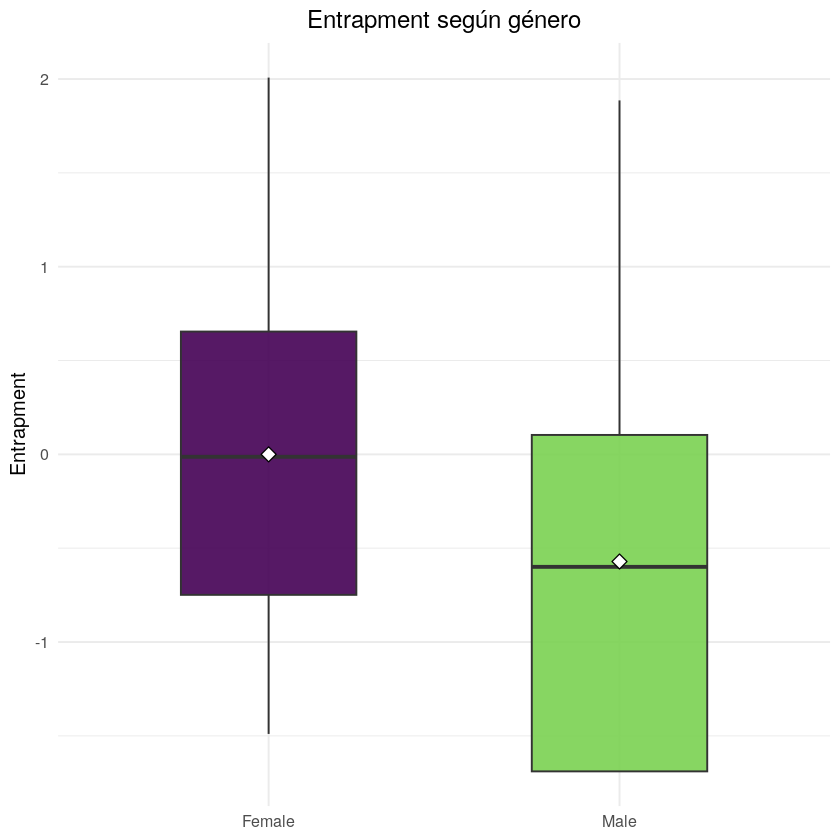

In [287]:
ggplot(d_gen, aes(x = Gender, y = Entrapment, fill = Gender)) +
  geom_boxplot(width = 0.5, alpha = 0.9, outlier.alpha = 0.4, show.legend = FALSE) +
  stat_summary(fun = mean, geom = "point", shape = 23, size = 3, fill = "white") +
  scale_fill_viridis_d(end = 0.8) +
  labs(title = "Entrapment según género",
       x = NULL, y = "Entrapment") +
  theme(legend.position = "none")

El rombo blanco indica la media de cada grupo. Las mujeres presentan valores más altos de entrapment (mediana cercana a 0) que los hombres (mediana ≈ -0.6), y la caja masculina llega hasta el extremo inferior de la escala, coherente con la acumulación de casos en el piso.

## *Apoyo social según género*

Se compara el nivel de cada dimensión del apoyo social entre mujeres y hombres.

In [288]:
df %>%
  filter(!is.na(Gender)) %>%
  select(Gender, all_of(support_vars[1:3])) %>%
  pivot_longer(-Gender, names_to = "Variable", values_to = "value") %>%
  filter(!is.na(value)) %>%
  group_by(Variable, Gender) %>%
  summarise(mean = round(mean(value), 3), sd = round(sd(value), 3), n = n(), .groups = "drop") %>%
  arrange(Variable, Gender) %>%
  gt() %>%
  tab_header(title = "Medias por género")

<div id="zgfmompgpz" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#zgfmompgpz table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#zgfmompgpz thead, #zgfmompgpz tbody, #zgfmompgpz tfoot, #zgfmompgpz tr, #zgfmompgpz td, #zgfmompgpz th {
  border-style: none;
}

#zgfmompgpz p {
  margin: 0;
  padding: 0;
}

#zgfmompgpz .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#zgfmompgpz .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#zgfmompgpz .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#zgfmompgpz .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#zgfmompgpz .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#zgfmompgpz .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#zgfmompgpz .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#zgfmompgpz .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#zgfmompgpz .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#zgfmompgpz .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#zgfmompgpz .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#zgfmompgpz .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#zgfmompgpz .gt_spanner_row {
  border-bottom-style: hidden;
}

#zgfmompgpz .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

Las diferencias entre mujeres y hombres en apoyo social son pequeñas. La más marcada ocurre en el apoyo familiar: las mujeres presentan una media de -0.094 (n = 347) frente a 0.165 en los hombres (n = 277), es decir, cerca de un cuarto de desviación estándar menos (d ≈ -0.26). En amigos (0.064 frente a -0.026) y en otras personas significativas (0.102 frente a -0.054) ocurre lo contrario, con ventaja leve para las mujeres, aunque las diferencias son de apenas 0.09 y 0.16 desviaciones estándar. Las desviaciones estándar son casi iguales entre géneros (entre 0.93 y 1.05), así que la variabilidad es comparable. Este patrón es relevante porque el apoyo familiar es la dimensión más asociada con el entrapment (r = -0.40): las mujeres, que tienen más entrapment, también perciben algo menos apoyo de su familia. Estas diferencias son descriptivas y se ponen a prueba a continuación.

In [289]:
res_apoyo <- map_dfr(apoyo_vars, function(v) {
  prueba_2grupos(df, v, "Gender") %>% mutate(Variable = v, .before = 1)
}) %>%
  group_by(Prueba) %>%
  mutate(p_holm = p.adjust(p, method = "holm")) %>%
  ungroup()

res_apoyo %>%
  formato_2grupos("Apoyo social por género (Female − Male)", groupname_col = "Variable") %>%
  fmt(columns = p_holm, fns = function(x) ifelse(x < 0.001, "< .001", sprintf("%.3f", x))) %>%
  cols_label(p_holm = "p (Holm)")

<div id="khvgkztaoc" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#khvgkztaoc table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#khvgkztaoc thead, #khvgkztaoc tbody, #khvgkztaoc tfoot, #khvgkztaoc tr, #khvgkztaoc td, #khvgkztaoc th {
  border-style: none;
}

#khvgkztaoc p {
  margin: 0;
  padding: 0;
}

#khvgkztaoc .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#khvgkztaoc .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#khvgkztaoc .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#khvgkztaoc .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#khvgkztaoc .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#khvgkztaoc .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#khvgkztaoc .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#khvgkztaoc .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#khvgkztaoc .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#khvgkztaoc .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#khvgkztaoc .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#khvgkztaoc .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#khvgkztaoc .gt_spanner_row {
  border-bottom-style: hidden;
}

#khvgkztaoc .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

Solo Family muestra una diferencia sólida entre géneros: los hombres perciben más apoyo familiar que las mujeres, con un efecto pequeño (d = -0.261, IC95% [-0.419, -0.104]; rango-biserial = -0.137) que se mantiene significativo tras la corrección de Holm en ambas pruebas (p = .003 y p = .010). En Friends no hay diferencia (d = 0.090, IC que incluye el cero; p = .264 y .151), y SigOthers queda en zona ambigua: la ventaja femenina es muy pequeña (d = 0.159) y las pruebas discrepan, pues Welch no la respalda tras Holm (p = .099, con un IC cuyo límite inferior es 0.000) y Wilcoxon sí (p = .027), por lo que conviene reportarla como diferencia mínima y no concluyente.

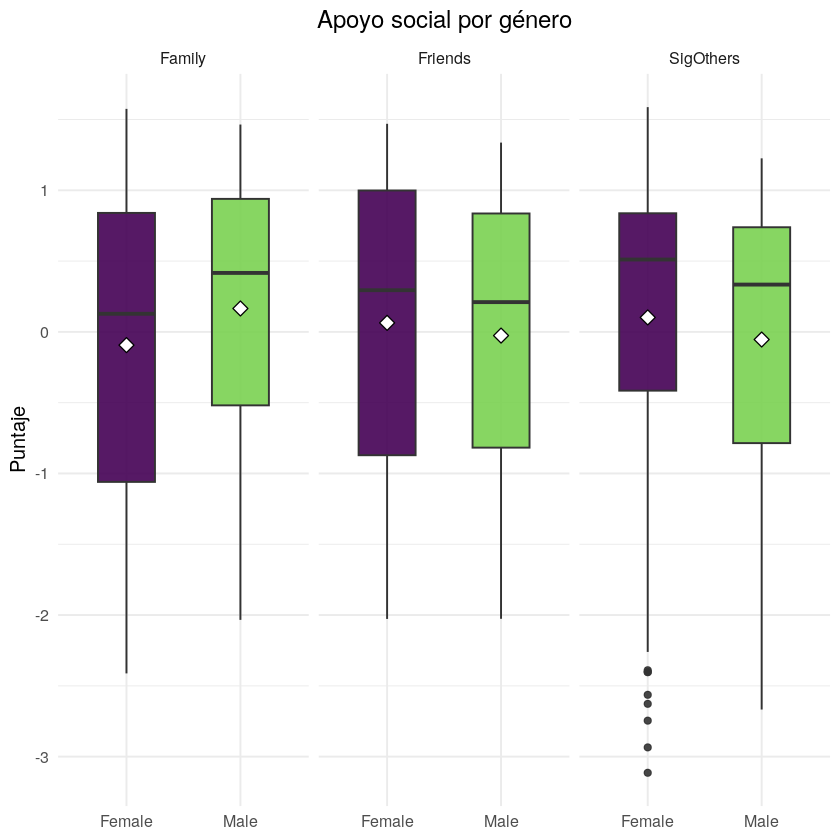

In [290]:
df %>%
  filter(!is.na(Gender)) %>%
  select(Gender, all_of(support_vars[1:3])) %>%
  pivot_longer(-Gender, names_to = "Variable", values_to = "value") %>%
  filter(!is.na(value)) %>%
  ggplot(aes(x = Gender, y = value, fill = Gender)) +
  geom_boxplot(width = 0.5, alpha = 0.9, show.legend = FALSE) +
  stat_summary(fun = mean, geom = "point", shape = 23, size = 3, fill = "white") +
  facet_wrap(~ Variable, nrow = 1) +
  scale_fill_viridis_d(end = 0.8) +
  labs(title = "Apoyo social por género",
       x = NULL, y = "Puntaje") +
  theme(plot.title = element_text(hjust = 0.5),
        plot.subtitle = element_text(hjust = 0.5))

Las diferencias son pequeñas y de signo distinto según la fuente. En Family, los hombres perciben más apoyo (mediana ≈ 0.4 frente a ≈ 0.1), y la caja de las mujeres se extiende más hacia valores bajos. En Friends y SigOthers ocurre lo contrario, con una ligera ventaja femenina, pero las cajas se solapan casi por completo. En SigOthers solo las mujeres muestran puntos atípicos en la cola inferior (entre -2.3 y -3.1), correspondientes a adolescentes con muy poco apoyo. Como ya se vio, la diferencia más relevante es la de Family, coherente con el mayor entrapment femenino, aunque el gráfico es solo descriptivo.

## *Apoyo social vs. entrapment*

Se examina la correlación de cada dimensión del apoyo social con el entrapment y de las dimensiones entre sí.

In [291]:
cor_mat <- df %>%
  select(Family, Friends, SigOthers, Entrapment) %>%
  cor(use = "pairwise.complete.obs") %>%
  round(3)

cor_mat

,Family,Friends,SigOthers,Entrapment
Family,1.000,0.433,0.521,-0.403
Friends,0.433,1.000,0.556,-0.221
SigOthers,0.521,0.556,1.000,-0.186
Entrapment,-0.403,-0.221,-0.186,1.000


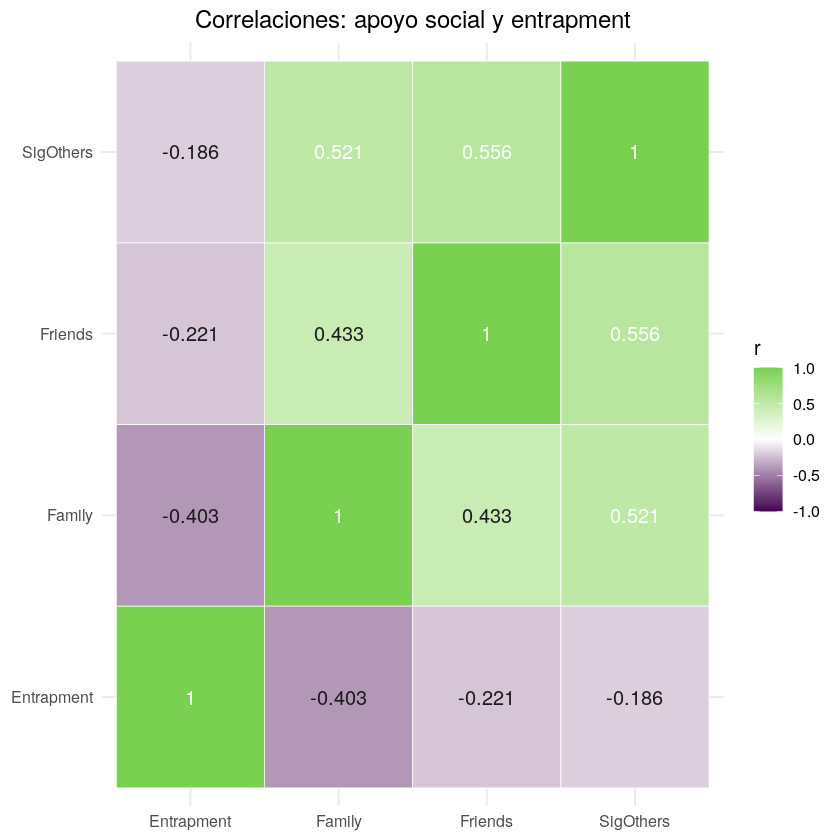

In [292]:
col_neg <- viridisLite::viridis(10, end = 0.8)[1]    
col_pos <- viridisLite::viridis(10, end = 0.8)[10]   

cor_mat %>%
  as.data.frame() %>%
  rownames_to_column("var1") %>%
  pivot_longer(-var1, names_to = "var2", values_to = "r") %>%
  ggplot(aes(x = var1, y = var2, fill = r)) +
  geom_tile(color = "white") +
  geom_text(aes(label = r, color = abs(r) > 0.5)) +
  scale_fill_gradient2(low = col_neg, mid = "white", high = col_pos,
                       midpoint = 0, limits = c(-1, 1), name = "r") +
  scale_color_manual(values = c(`TRUE` = "white", `FALSE` = "grey10"), guide = "none") +
  labs(title = "Correlaciones: apoyo social y entrapment", x = NULL, y = NULL) +
  theme(plot.title = element_text(hjust = 0.5))

El mapa de calor muestra que las tres dimensiones de apoyo se asocian de forma negativa con el entrapment, es decir, a mayor apoyo percibido, menor sensación de estar atrapado, aunque con fuerza distinta según la fuente: la familia presenta la relación más marcada (r = -0.403, moderada), aproximadamente el doble que la de los amigos (r = -0.221) y la de otras personas significativas (r = -0.186), ambas débiles.

In [293]:
cor_apoyo <- map_dfr(c("Family", "Friends", "SigOthers"), function(v) {
  d <- df %>% select(x = all_of(v), y = Entrapment) %>% drop_na()
  p <- cor.test(d$x, d$y, method = "pearson")
  s <- cor.test(d$x, d$y, method = "spearman", exact = FALSE)

  # IC95% de Spearman con transformación z de Fisher (aproximación de Bonett-Wright)
  n <- nrow(d)
  rho <- unname(s$estimate)
  s_ic <- tanh(atanh(rho) + c(-1, 1) * 1.96 * sqrt((1 + rho^2 / 2) / (n - 3)))

  tibble(
    Variable = v,
    Prueba = c("Pearson", "Spearman"),
    n = n,
    Correlación = c(unname(p$estimate), rho),
    `IC95%` = c(sprintf("[%.3f, %.3f]", p$conf.int[1], p$conf.int[2]),
                sprintf("[%.3f, %.3f]", s_ic[1], s_ic[2])),
    p = c(p$p.value, s$p.value)
  )
})

cor_apoyo %>%
  gt(groupname_col = "Variable") %>%
  fmt_number(Correlación, decimals = 3) %>%
  fmt(columns = p, fns = function(x) ifelse(x < 0.001, "< .001", sprintf("%.3f", x))) %>%
  tab_header(title = "Apoyo social vs. entrapment")

<div id="hdaordioux" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#hdaordioux table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#hdaordioux thead, #hdaordioux tbody, #hdaordioux tfoot, #hdaordioux tr, #hdaordioux td, #hdaordioux th {
  border-style: none;
}

#hdaordioux p {
  margin: 0;
  padding: 0;
}

#hdaordioux .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#hdaordioux .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#hdaordioux .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#hdaordioux .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#hdaordioux .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#hdaordioux .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#hdaordioux .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#hdaordioux .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#hdaordioux .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#hdaordioux .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#hdaordioux .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#hdaordioux .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#hdaordioux .gt_spanner_row {
  border-bottom-style: hidden;
}

#hdaordioux .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

Las tres dimensiones del apoyo social se asocian de forma negativa y significativa con el entrapment (p < .001 con ambos métodos): a mayor apoyo percibido, menor sensación de estar atrapado. La asociación es moderada para la familia (Pearson r = -0.403, IC95% [-0.467, -0.334]) y débil para los amigos (r = -0.221) y las otras personas significativas (r = -0.186), lo que confirma que el apoyo familiar es la fuente más relacionada con el entrapment, aproximadamente el doble que las otras dos. Pearson y Spearman coinciden en las tres dimensiones (por ejemplo, -0.403 frente a -0.393 en Family), por lo que la relación no depende del efecto piso del entrapment ni de la asimetría del apoyo, y los intervalos casi se solapan por completo. Cada correlación se calculó con 615 casos, los que tienen a la vez apoyo y entrapment. Se trata de asociaciones y no de efectos: en datos transversales no es posible saber si el apoyo reduce el entrapment o si quienes se sienten más atrapados perciben menos apoyo.

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


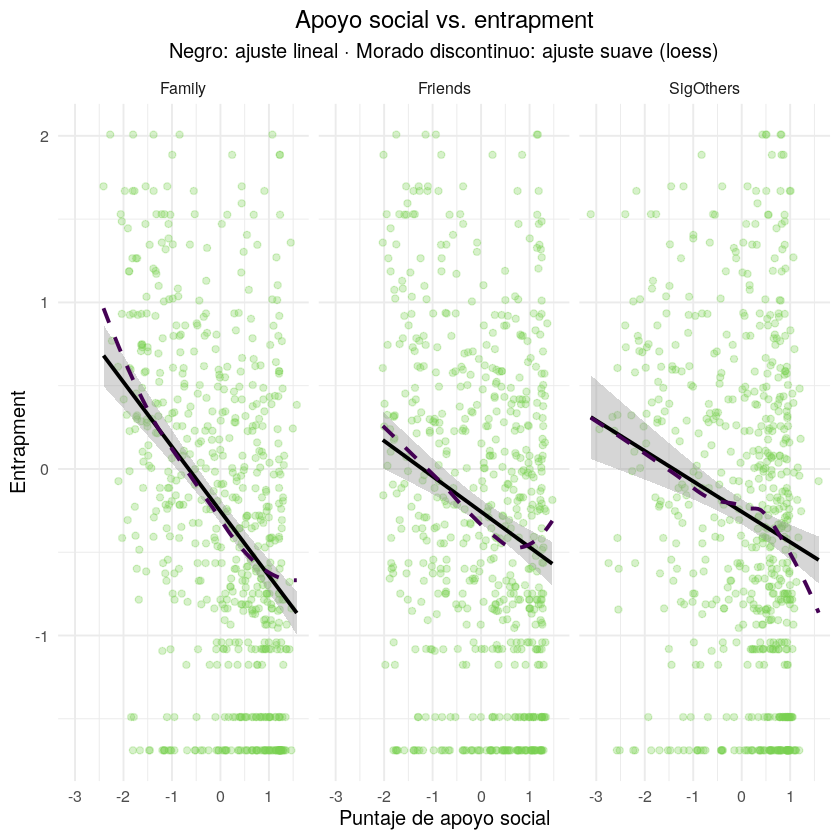

In [294]:
df %>%
  select(Entrapment, Family, Friends, SigOthers) %>%
  pivot_longer(-Entrapment, names_to = "Apoyo", values_to = "valor") %>%
  drop_na() %>%
  ggplot(aes(x = valor, y = Entrapment)) +
  geom_point(alpha = 0.3, color = col_verde) +
  geom_smooth(method = "lm", se = TRUE, color = "black") +
  geom_smooth(method = "loess", se = FALSE,
              color = col_morado, linetype = "dashed") +
  facet_wrap(~ Apoyo, nrow = 1) +
  labs(title = "Apoyo social vs. entrapment",
       subtitle = "Negro: ajuste lineal · Morado discontinuo: ajuste suave (loess)",
       x = "Puntaje de apoyo social", y = "Entrapment")

El gráfico confirma lo que mostraba la tabla: en las tres dimensiones la recta desciende, y la pendiente es claramente más pronunciada en Family, donde el entrapment pasa de cerca de 0.7 con bajo apoyo a cerca de -0.85 con alto apoyo, mientras que en Friends y SigOthers la caída es más suave. La curva suave (loess) sigue de cerca a la recta en el tramo central de las tres, por lo que la relación es razonablemente lineal; solo se separa en los extremos, donde hay pocos casos y la banda de confianza se ensancha, con una caída algo más marcada al final de SigOthers y un aplanamiento en Family, aunque sin suficiente evidencia para hablar de una no linealidad clara.

## *Correlación de Pearson con jackknife*
Se calcula la correlación de Pearson entre `Family`, `Friends`, `SigOthers` y `Entrapment` (seis pares, con los casos completos de cada par) y se aplica un jackknife *leave-one-out*: se recalcula la correlación excluyendo cada observación y, sobre la escala z de Fisher, se obtienen el estimador corregido por sesgo, el sesgo, el error estándar jackknife y el IC95%, que se transforma de vuelta a la escala de r para compararlo con el IC95% clásico de `cor.test`.

In [311]:
# Correlación de Pearson por pares (casos completos por par) + jackknife leave-one-out.
vars_cor <- c("Family", "Friends", "SigOthers", "Entrapment")
pares <- combn(vars_cor, 2, simplify = FALSE)

jack_cor <- map_dfr(pares, function(par) {
  d <- df %>% select(x = all_of(par[1]), y = all_of(par[2])) %>% drop_na()
  n <- nrow(d)

  ct <- cor.test(d$x, d$y, method = "pearson")
  r0 <- unname(ct$estimate)

  # Jackknife sobre la z de Fisher: r se transforma, se remuestrea y se devuelve a escala r
  r_i <- vapply(seq_len(n), function(i) cor(d$x[-i], d$y[-i]), numeric(1))
  z0  <- atanh(r0)
  z_i <- atanh(r_i)
  sesgo_z <- (n - 1) * (mean(z_i) - z0)
  z_jack  <- z0 - sesgo_z                                     # r corregido por sesgo
  ee_z    <- sqrt((n - 1) / n * sum((z_i - mean(z_i))^2))     # EE jackknife (escala z)
  ic_jack <- tanh(z_jack + c(-1, 1) * qnorm(0.975) * ee_z)

  tibble(
    Par = paste(par[1], "–", par[2]),
    n = n,
    r = r0,
    `r jackknife` = tanh(z_jack),
    Sesgo = tanh(z_jack) - r0,
    `EE jackknife` = ee_z,
    `IC95% jackknife` = sprintf("[%.3f, %.3f]", ic_jack[1], ic_jack[2]),
    `IC95% cor.test`  = sprintf("[%.3f, %.3f]", ct$conf.int[1], ct$conf.int[2]),
    `Δr máx` = max(abs(r_i - r0))                             # caso más influyente
  )
})

jack_cor %>%
  gt() %>%
  fmt_number(c(r, `r jackknife`), decimals = 3) %>%
  fmt_number(c(Sesgo, `EE jackknife`, `Δr máx`), decimals = 4) %>%
  tab_header(title = "Correlación de Pearson con jackknife",
             subtitle = "Leave-one-out sobre la z de Fisher, con el IC95% clásico como referencia") %>%
  tab_source_note("El EE jackknife está en la escala z de Fisher; el IC95% se calcula en esa escala y se transforma de vuelta a r. Δr máx es el mayor cambio en r al excluir un solo caso.")

El EE jackknife está en la escala z de Fisher; el IC95% se calcula en esa escala y se transforma de vuelta a r. Δr máx es el mayor cambio en r al excluir un solo caso.


Ninguna de las seis correlaciones depende de un puñado de casos. El sesgo jackknife es despreciable en todos los pares (entre 0.0003 y 0.0007 en valor absoluto), de modo que la r corregida coincide con la original hasta el tercer decimal (por ejemplo, -0.403 frente a -0.402 en Family–Entrapment).

Los errores estándar jackknife son muy parecidos entre pares (0.041–0.045 en la escala z) y los intervalos resultantes son apenas más anchos que los de `cor.test` (del orden de 0.006 a 0.008 en cada extremo). Los dos criterios coinciden en el signo, la magnitud y la exclusión del cero en los seis pares. El par con mayor Δr máx (0.0078) es justamente SigOthers–Entrapment, pero tiene un desplazamiento de 0.008 sobre una r de -0.186 , es decir, la asociación sigue siendo débil y negativa. En conjunto, las tres dimensiones de apoyo siguen correlacionadas entre sí entre 0.43 y 0.56.

## *Apoyo social vs. entrapment según género*


`geom_smooth()` using formula = 'y ~ x'


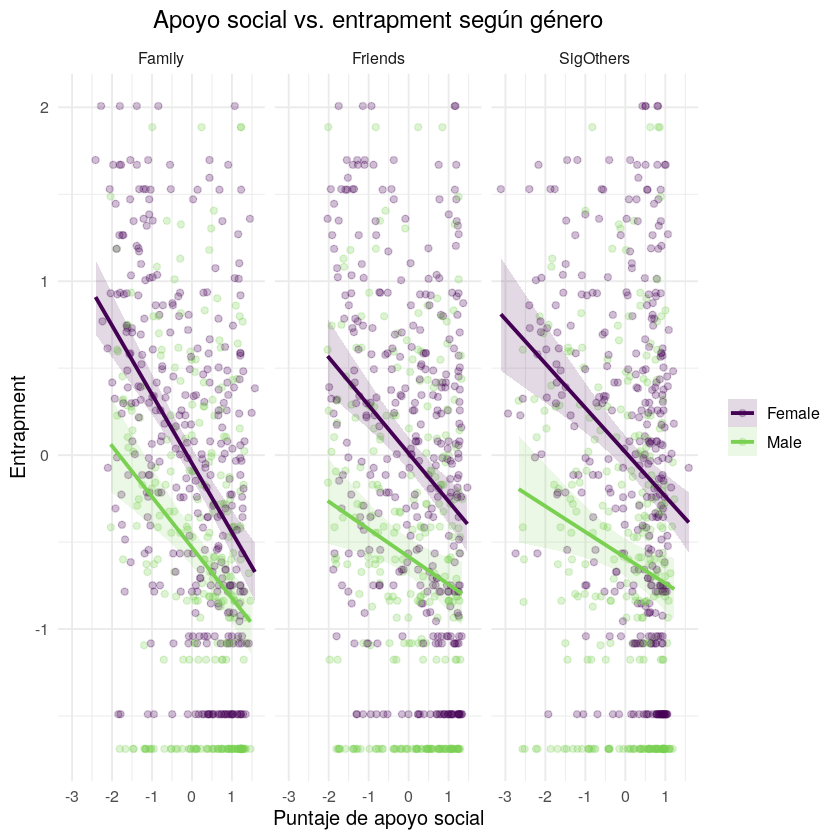

In [295]:
df %>%
  filter(!is.na(Gender)) %>%
  select(Gender, Entrapment, Family, Friends, SigOthers) %>%
  pivot_longer(c(Family, Friends, SigOthers), names_to = "Apoyo", values_to = "valor") %>%
  drop_na() %>%
  ggplot(aes(x = valor, y = Entrapment, color = Gender, fill = Gender)) +
  geom_point(alpha = 0.25) +
  geom_smooth(method = "lm", se = TRUE, alpha = 0.15) +
  facet_wrap(~ Apoyo, nrow = 1) +
  scale_color_viridis_d(end = 0.8) +
  scale_fill_viridis_d(end = 0.8) +
  labs(title = "Apoyo social vs. entrapment según género",
       x = "Puntaje de apoyo social", y = "Entrapment", color = NULL, fill = NULL)

En las tres dimensiones la recta de las mujeres (morado) queda por encima de la de los hombres (verde), lo que refleja el mayor entrapment femenino que ya conocíamos (efecto principal del género). Lo relevante para la moderación es la inclinación: la recta de las mujeres desciende más que la de los hombres en Family, Friends y SigOthers, sobre todo en Family, donde la brecha entre ambos grupos se reduce a medida que aumenta el apoyo. Es un indicio visual de que el apoyo podría asociarse con menos entrapment en mujeres que en hombres, aunque las bandas de confianza se solapan en buena parte del rango. Además, los hombres acumulan muchos casos en el piso del entrapment (filas de puntos verdes en el mínimo), lo que puede aplanar su pendiente sin que refleje una diferencia real en la relación.

In [296]:
cor_genero <- map_dfr(apoyo_vars, function(v) {
  d <- df %>% select(Gender, x = all_of(v), y = Entrapment) %>% drop_na()
  f <- d %>% filter(Gender == "Female")
  m <- d %>% filter(Gender == "Male")

  cf <- cor.test(f$x, f$y)
  cm <- cor.test(m$x, m$y)

  # Comparación de las dos correlaciones (z de Fisher)
  z <- (atanh(cf$estimate) - atanh(cm$estimate)) /
       sqrt(1 / (nrow(f) - 3) + 1 / (nrow(m) - 3))

  tibble(
    Apoyo = v,
    `n (F)` = nrow(f), `r (F)` = unname(cf$estimate),
    `IC95% (F)` = sprintf("[%.3f, %.3f]", cf$conf.int[1], cf$conf.int[2]),
    `n (M)` = nrow(m), `r (M)` = unname(cm$estimate),
    `IC95% (M)` = sprintf("[%.3f, %.3f]", cm$conf.int[1], cm$conf.int[2]),
    `Diferencia (F − M)` = unname(cf$estimate - cm$estimate),
    z = unname(z),
    p = 2 * pnorm(-abs(unname(z)))
  )
}) %>%
  mutate(p_holm = p.adjust(p, method = "holm"))

cor_genero %>%
  gt() %>%
  fmt_number(c(`r (F)`, `r (M)`, `Diferencia (F − M)`, z), decimals = 3) %>%
  fmt(columns = c(p, p_holm), fns = function(x) ifelse(x < 0.001, "< .001", sprintf("%.3f", x))) %>%
  cols_label(p_holm = "p (Holm)") %>%
  tab_header(title = "Correlación apoyo social-entrapment por género")

<div id="kaijqugfns" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#kaijqugfns table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#kaijqugfns thead, #kaijqugfns tbody, #kaijqugfns tfoot, #kaijqugfns tr, #kaijqugfns td, #kaijqugfns th {
  border-style: none;
}

#kaijqugfns p {
  margin: 0;
  padding: 0;
}

#kaijqugfns .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#kaijqugfns .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#kaijqugfns .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#kaijqugfns .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#kaijqugfns .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#kaijqugfns .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#kaijqugfns .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#kaijqugfns .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#kaijqugfns .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#kaijqugfns .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#kaijqugfns .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#kaijqugfns .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#kaijqugfns .gt_spanner_row {
  border-bottom-style: hidden;
}

#kaijqugfns .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

El apoyo social se asocia con menos entrapment en ambos géneros, pero la asociación es más fuerte en las mujeres en las tres dimensiones: Family (r = -0.448 frente a -0.293), Friends (-0.303 frente a -0.170) y SigOthers (-0.270 frente a -0.158). Sin embargo, solo la diferencia en Family alcanza significancia (z = -2.205, p = .027), y aun así no se sostendría con una corrección por comparaciones múltiples; en Friends (p = .083) y SigOthers (p = .152) no es significativa.

## *Covariables categóricas vs. entrapment*

In [297]:
# Covariables con niveles ordenados. SSE se colapsa: High tiene solo 7 casos.
df_cov <- df %>%
  mutate(
    Grade        = factor(Grade, levels = c("9", "10", "11")),
    Municipality = factor(Municipality, levels = c("Polo Nuevo", "Santo Tomas", "Puerto Colombia", "Suan")),
    Ethnicity    = factor(Ethnicity, levels = c("Mestizo", "Caucasian", "Afrodescendant", "Other")),
    SSE          = factor(case_when(SSE == "Low" ~ "Low",
                                    SSE %in% c("Medium", "High") ~ "Medium/High"),
                          levels = c("Low", "Medium/High")),
    Education    = factor(Education, levels = c("Primary", "High School", "Undergraduate", "Graduate")),
    Age_grupo    = factor(case_when(Age <= 14 ~ "≤ 14", Age == 15 ~ "15", Age == 16 ~ "16",
                                    Age == 17 ~ "17", Age >= 18 ~ "≥ 18"),
                          levels = c("≤ 14", "15", "16", "17", "≥ 18"))
  )

# Boxplot de entrapment según una covariable (paleta morado-verde)
boxplot_cov <- function(data, var, titulo, xlab) {
  data %>%
    select(g = all_of(var), Entrapment) %>%
    drop_na() %>%
    ggplot(aes(x = g, y = Entrapment, fill = g)) +
    geom_boxplot(width = 0.5, alpha = 0.9, show.legend = FALSE) +
    stat_summary(fun = mean, geom = "point", shape = 23, size = 3, fill = "white") +
    scale_fill_viridis_d(end = 0.8) +
    labs(title = titulo, x = xlab, y = "Entrapment")
}

# Pruebas para covariables con 3 o más grupos: ANOVA de Welch y Kruskal-Wallis
tabla_grupos <- function(data, var, titulo) {
  d <- data %>%
    select(g = all_of(var), y = Entrapment) %>%
    drop_na() %>%
    mutate(g = droplevels(g))

  n  <- nrow(d)
  k  <- nlevels(d$g)
  aw <- oneway.test(y ~ g, data = d, var.equal = FALSE)     # ANOVA de Welch
  kw <- kruskal.test(y ~ g, data = d)                        # Kruskal-Wallis

  # η² = suma de cuadrados entre grupos / suma de cuadrados total
  medias <- tapply(d$y, d$g, mean)
  ns     <- tapply(d$y, d$g, length)
  ss_entre <- sum(ns * (medias - mean(d$y))^2)
  ss_total <- sum((d$y - mean(d$y))^2)
  eta2 <- as.numeric(ss_entre / ss_total)

  eps2 <- as.numeric(kw$statistic) / (n - 1)                 # ε² de Kruskal-Wallis

  tibble(
    Prueba = c("ANOVA de Welch", "Kruskal-Wallis"),
    n = n,
    Estadístico = c(as.numeric(aw$statistic), as.numeric(kw$statistic)),
    gl = c(sprintf("%d, %.1f", k - 1, aw$parameter[2]), sprintf("%d", k - 1)),
    p = c(aw$p.value, kw$p.value),
    `Tamaño del efecto` = c(eta2, eps2),
    Medida = c("η²", "ε²")
  ) %>%
    gt() %>%
    fmt_number(c(Estadístico, `Tamaño del efecto`), decimals = 3) %>%
    fmt(columns = p, fns = function(x) ifelse(x < 0.001, "< .001", sprintf("%.3f", x))) %>%
    tab_header(title = titulo)
}

### *Edad vs. entrapment*

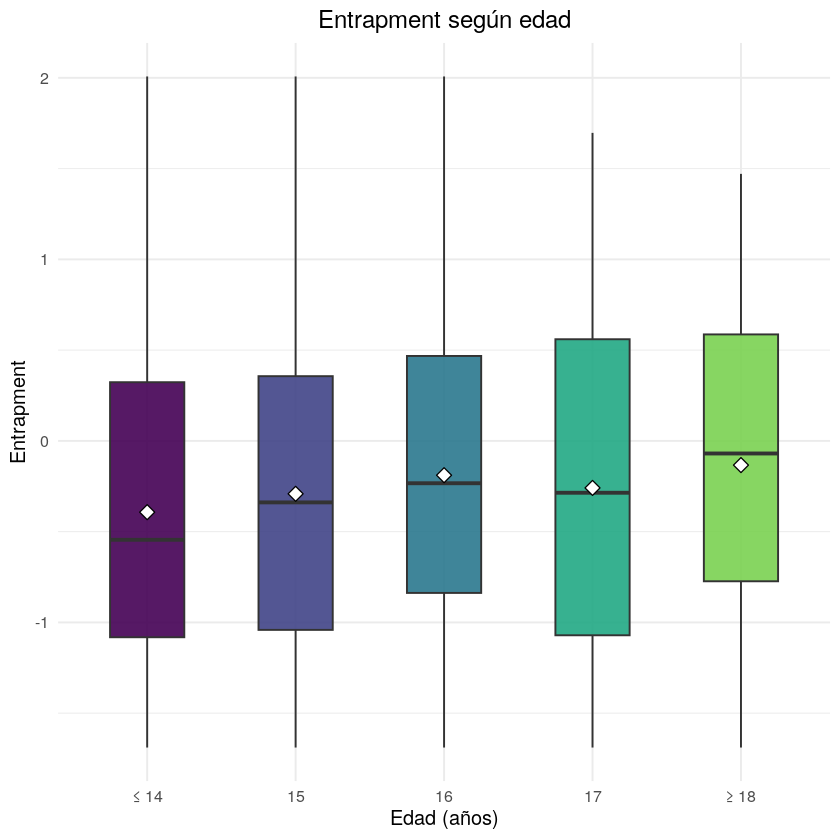

In [298]:
boxplot_cov(df_cov, "Age_grupo", "Entrapment según edad", "Edad (años)")

La distribución del entrapment es muy similar en todos los grupos de edad: las medianas quedan por debajo de cero y las cajas se solapan casi por completo. Se observa un leve aumento con la edad (de una mediana cercana a -0.55 en ≤ 14 años a -0.07 en ≥ 18), pero es mínimo frente a la dispersión

In [299]:
d_age <- df %>% select(Age, Entrapment) %>% drop_na()
p_age <- cor.test(d_age$Age, d_age$Entrapment, method = "pearson")
s_age <- cor.test(d_age$Age, d_age$Entrapment, method = "spearman", exact = FALSE)

tibble(
  Prueba = c("Pearson", "Spearman"),
  n = nrow(d_age),
  Correlación = c(unname(p_age$estimate), unname(s_age$estimate)),
  p = c(p_age$p.value, s_age$p.value)
) %>%
  gt() %>%
  fmt_number(Correlación, decimals = 3) %>%
  fmt(columns = p, fns = function(x) ifelse(x < 0.001, "< .001", sprintf("%.3f", x))) %>%
  tab_header(title = "Edad vs. entrapment")

<div id="vdjnfhivfi" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#vdjnfhivfi table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#vdjnfhivfi thead, #vdjnfhivfi tbody, #vdjnfhivfi tfoot, #vdjnfhivfi tr, #vdjnfhivfi td, #vdjnfhivfi th {
  border-style: none;
}

#vdjnfhivfi p {
  margin: 0;
  padding: 0;
}

#vdjnfhivfi .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#vdjnfhivfi .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#vdjnfhivfi .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#vdjnfhivfi .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#vdjnfhivfi .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#vdjnfhivfi .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#vdjnfhivfi .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#vdjnfhivfi .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#vdjnfhivfi .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#vdjnfhivfi .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#vdjnfhivfi .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#vdjnfhivfi .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#vdjnfhivfi .gt_spanner_row {
  border-bottom-style: hidden;
}

#vdjnfhivfi .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

La edad no se asocia con el entrapment en esta muestra. Con 656 casos, la correlación es prácticamente nula y muy similar con ambos métodos (Pearson r = 0.060, p = .122; Spearman ρ = 0.059, p = .128), sin alcanzar significancia. En términos de magnitud, r = 0.06 implica que la edad explica menos del 0.4% de la variación del entrapment. Que Pearson y Spearman coincidan indica que el resultado no depende del efecto piso ni de valores extremos.

### *Grado escolar vs. entrapment*

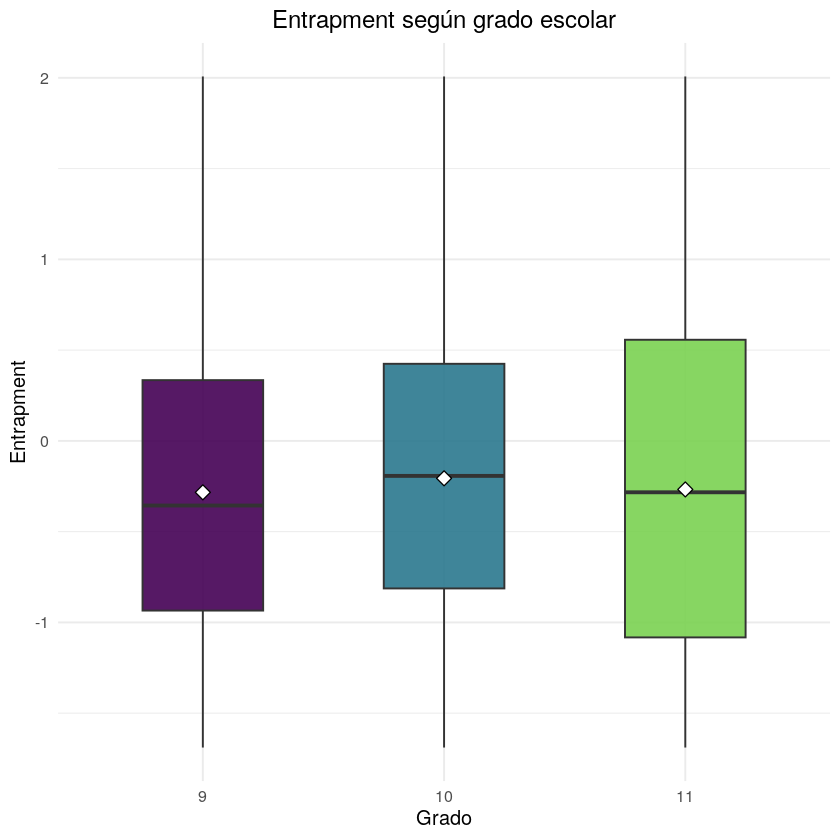

In [300]:
boxplot_cov(df_cov, "Grade", "Entrapment según grado escolar", "Grado")

La distribución del entrapment es casi idéntica en los tres grados: las medianas se ubican entre -0.36 y -0.19 y las medias entre -0.28 y -0.20, con cajas que se solapan casi por completo y bigotes que cubren todo el rango de la escala. No hay una tendencia clara con el grado (10.º tiene la mediana algo más alta, pero 11.º vuelve a bajar), y en 11.º la caja es algo más ancha, es decir, con más variabilidad entre estudiantes. Esto es coherente con lo observado en la edad, con la que el grado está estrechamente relacionado, y sugiere que el grado escolar no se asocia de forma apreciable con el entrapment.

In [301]:
tabla_grupos(df_cov, "Grade", "Grado escolar vs. entrapment")

<div id="bhhyqxmuib" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#bhhyqxmuib table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#bhhyqxmuib thead, #bhhyqxmuib tbody, #bhhyqxmuib tfoot, #bhhyqxmuib tr, #bhhyqxmuib td, #bhhyqxmuib th {
  border-style: none;
}

#bhhyqxmuib p {
  margin: 0;
  padding: 0;
}

#bhhyqxmuib .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#bhhyqxmuib .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#bhhyqxmuib .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#bhhyqxmuib .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#bhhyqxmuib .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#bhhyqxmuib .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#bhhyqxmuib .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#bhhyqxmuib .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#bhhyqxmuib .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#bhhyqxmuib .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#bhhyqxmuib .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#bhhyqxmuib .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#bhhyqxmuib .gt_spanner_row {
  border-bottom-style: hidden;
}

#bhhyqxmuib .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

Ninguna de las dos pruebas detecta diferencias en el entrapment entre 9.º, 10.º y 11.º (ANOVA de Welch p = .683; Kruskal-Wallis p = .571), y los tamaños del efecto son prácticamente nulos: el grado explica menos del 0.2% de la variación.

### *Municipio vs. entrapment*

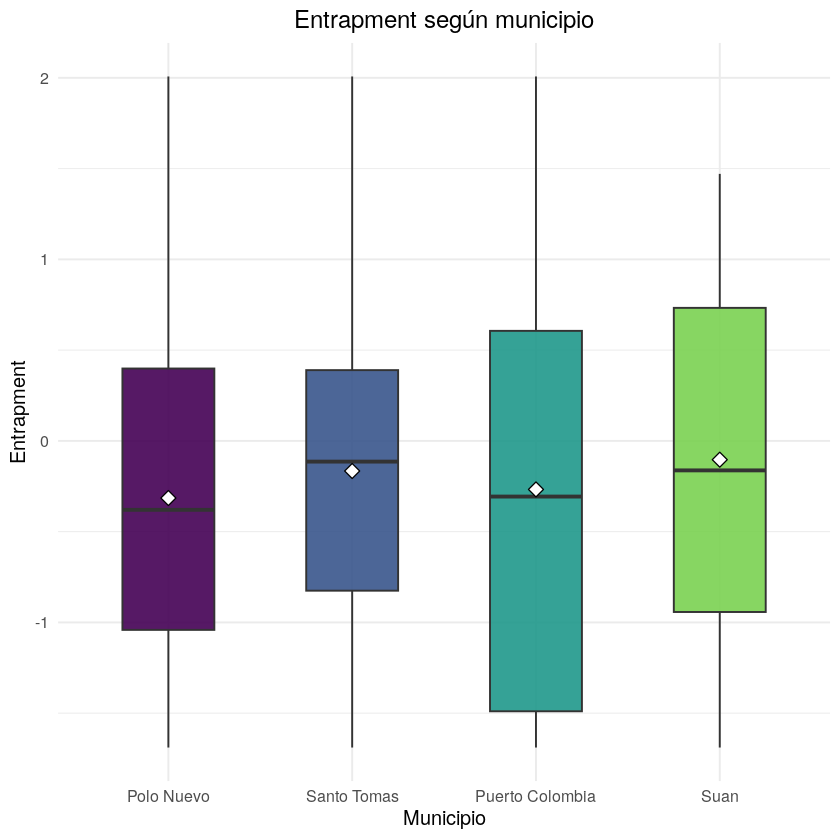

In [302]:
boxplot_cov(df_cov, "Municipality", "Entrapment según municipio", "Municipio")

El entrapment es muy parecido entre los cuatro municipios: las medianas quedan por debajo de cero en todos y las cajas se solapan casi por completo. Polo Nuevo tiene los valores algo más bajos y Suan y Santo Tomás los más altos, pero las diferencias son pequeñas frente a la dispersión de cada grupo.

In [303]:
tabla_grupos(df_cov, "Municipality", "Municipio vs. entrapment")

<div id="twnnxhrqax" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#twnnxhrqax table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#twnnxhrqax thead, #twnnxhrqax tbody, #twnnxhrqax tfoot, #twnnxhrqax tr, #twnnxhrqax td, #twnnxhrqax th {
  border-style: none;
}

#twnnxhrqax p {
  margin: 0;
  padding: 0;
}

#twnnxhrqax .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#twnnxhrqax .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#twnnxhrqax .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#twnnxhrqax .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#twnnxhrqax .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#twnnxhrqax .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#twnnxhrqax .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#twnnxhrqax .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#twnnxhrqax .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#twnnxhrqax .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#twnnxhrqax .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#twnnxhrqax .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#twnnxhrqax .gt_spanner_row {
  border-bottom-style: hidden;
}

#twnnxhrqax .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

Las pruebas lo confirman: ni el ANOVA de Welch (p = .308) ni Kruskal-Wallis (p = .282) detectan diferencias, y el municipio explica menos del 1% de la variación del entrapment. Suan, con solo 25 estudiantes, es el grupo menos estable. Conviene incluir el municipio en los modelos por criterio de diseño, ya que los estudiantes están agrupados por colegio, aunque en el bivariado no se asocie con el entrapment.

### *Etnia vs. entrapment*

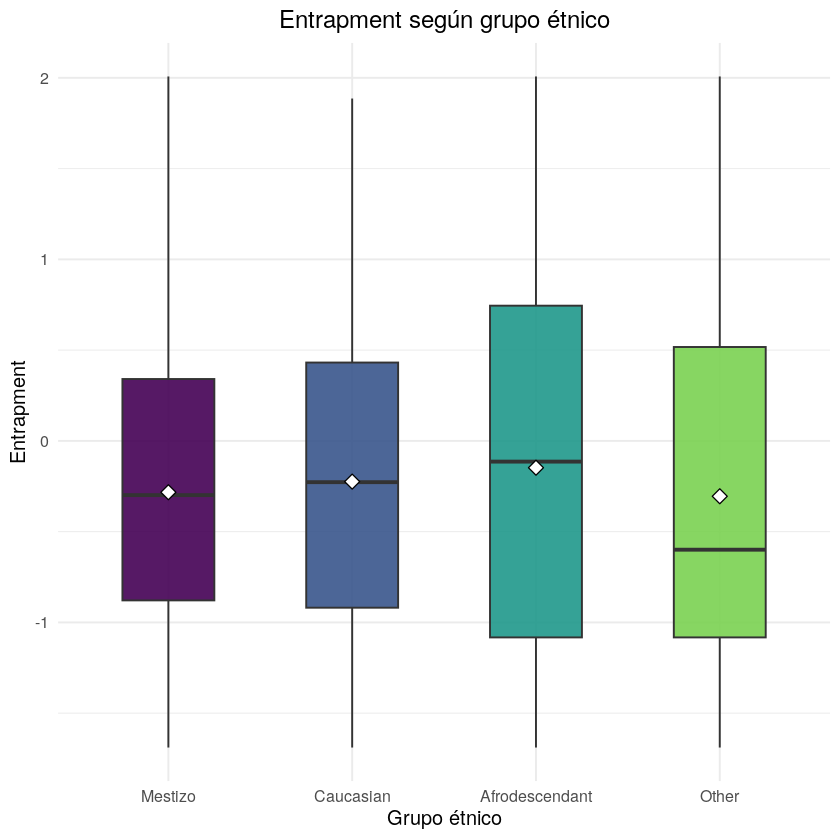

In [304]:
boxplot_cov(df_cov, "Ethnicity", "Entrapment según grupo étnico", "Grupo étnico")

El entrapment es muy similar entre los cuatro grupos étnicos: las medianas quedan por debajo de cero en todos y las cajas se solapan casi por completo. Los afrodescendientes muestran la mediana algo más alta y el grupo Other la más baja, pero las diferencias son pequeñas frente a la dispersión de cada grupo.

In [305]:
tabla_grupos(df_cov, "Ethnicity", "Grupo étnico vs. entrapment")

<div id="pgavzkbkvp" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#pgavzkbkvp table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#pgavzkbkvp thead, #pgavzkbkvp tbody, #pgavzkbkvp tfoot, #pgavzkbkvp tr, #pgavzkbkvp td, #pgavzkbkvp th {
  border-style: none;
}

#pgavzkbkvp p {
  margin: 0;
  padding: 0;
}

#pgavzkbkvp .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#pgavzkbkvp .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#pgavzkbkvp .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#pgavzkbkvp .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#pgavzkbkvp .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#pgavzkbkvp .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#pgavzkbkvp .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#pgavzkbkvp .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#pgavzkbkvp .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#pgavzkbkvp .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#pgavzkbkvp .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#pgavzkbkvp .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#pgavzkbkvp .gt_spanner_row {
  border-bottom-style: hidden;
}

#pgavzkbkvp .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

Las pruebas lo confirman: ni el ANOVA de Welch (p = .677) ni Kruskal-Wallis (p = .637) detectan diferencias, y la etnia explica menos del 1% de la variación del entrapment. Además, Other reúne categorías distintas y la variable tiene un 8% de datos faltantes (613 casos analizados), por lo que no aporta información propia en el bivariado.

### *Nivel socioeconómico vs. entrapment*

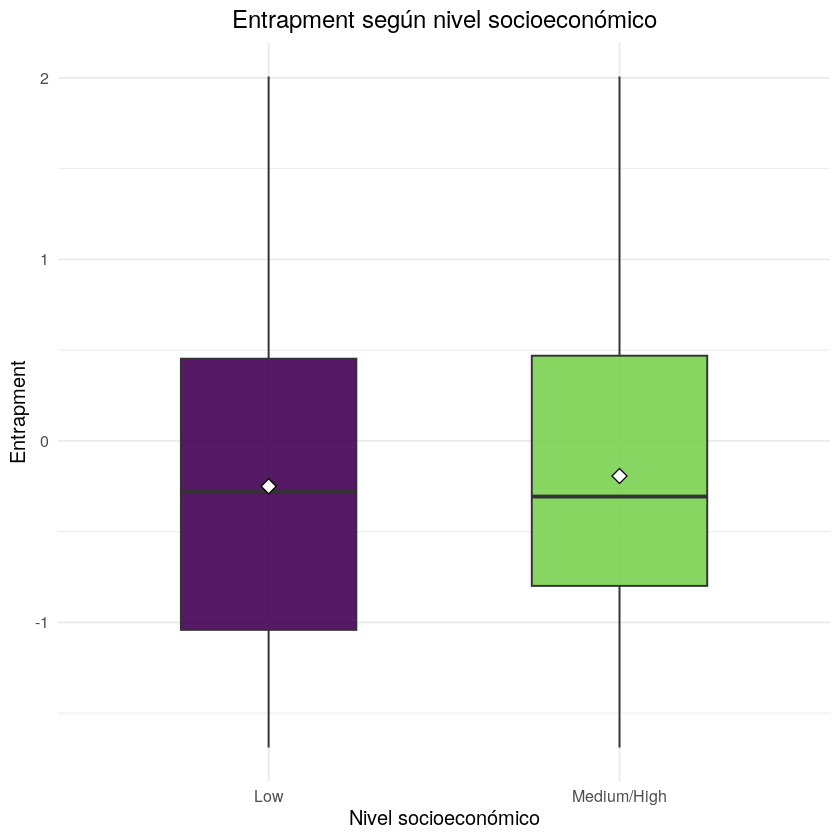

In [306]:
boxplot_cov(df_cov, "SSE", "Entrapment según nivel socioeconómico", "Nivel socioeconómico")

El entrapment es prácticamente igual en los dos grupos: las medianas y las medias casi coinciden y las cajas se solapan por completo.

In [307]:
d_sse <- df_cov %>% select(g = SSE, y = Entrapment) %>% drop_na()

tt <- t.test(y ~ g, data = d_sse)
wt <- wilcox.test(y ~ g, data = d_sse, conf.int = TRUE, exact = FALSE)
dd <- cohens_d(y ~ g, data = d_sse, pooled_sd = FALSE)
rb <- rank_biserial(y ~ g, data = d_sse)

tibble(
  Prueba = c("Welch (t)", "Wilcoxon"),
  Estadístico = c(unname(tt$statistic), unname(wt$statistic)),
  p = c(tt$p.value, wt$p.value),
  `Tamaño del efecto` = c(dd$Cohens_d, rb$r_rank_biserial),
  Medida = c("d de Cohen", "r rango-biserial"),
  `IC95%` = c(sprintf("[%.3f, %.3f]", dd$CI_low, dd$CI_high),
              sprintf("[%.3f, %.3f]", rb$CI_low, rb$CI_high))
) %>%
  gt() %>%
  fmt_number(c(Estadístico, `Tamaño del efecto`), decimals = 3) %>%
  fmt(columns = p, fns = function(x) ifelse(x < 0.001, "< .001", sprintf("%.3f", x))) %>%
  tab_header(title = "Nivel socioeconómico vs. entrapment (Low − Medium/High)")

<div id="anyiatkhuw" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#anyiatkhuw table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#anyiatkhuw thead, #anyiatkhuw tbody, #anyiatkhuw tfoot, #anyiatkhuw tr, #anyiatkhuw td, #anyiatkhuw th {
  border-style: none;
}

#anyiatkhuw p {
  margin: 0;
  padding: 0;
}

#anyiatkhuw .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#anyiatkhuw .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#anyiatkhuw .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#anyiatkhuw .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#anyiatkhuw .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#anyiatkhuw .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#anyiatkhuw .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#anyiatkhuw .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#anyiatkhuw .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#anyiatkhuw .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#anyiatkhuw .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#anyiatkhuw .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#anyiatkhuw .gt_spanner_row {
  border-bottom-style: hidden;
}

#anyiatkhuw .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

Ni la t de Welch (p = .571) ni Wilcoxon (p = .656) detectan diferencias, y los tamaños del efecto son nulos (d = -0.06, con un intervalo que incluye el cero). Que ambas pruebas coincidan indica que el resultado no depende del efecto piso. Es una comparación limitada, porque la muestra es casi toda de nivel bajo (72.5%) y el grupo Medium/High reúne a pocos estudiantes; además, esta variable tiene un 10% de datos faltantes. En el bivariado, el nivel socioeconómico no se asocia con el entrapment.

### *Nivel educativo de los padres vs. entrapment*

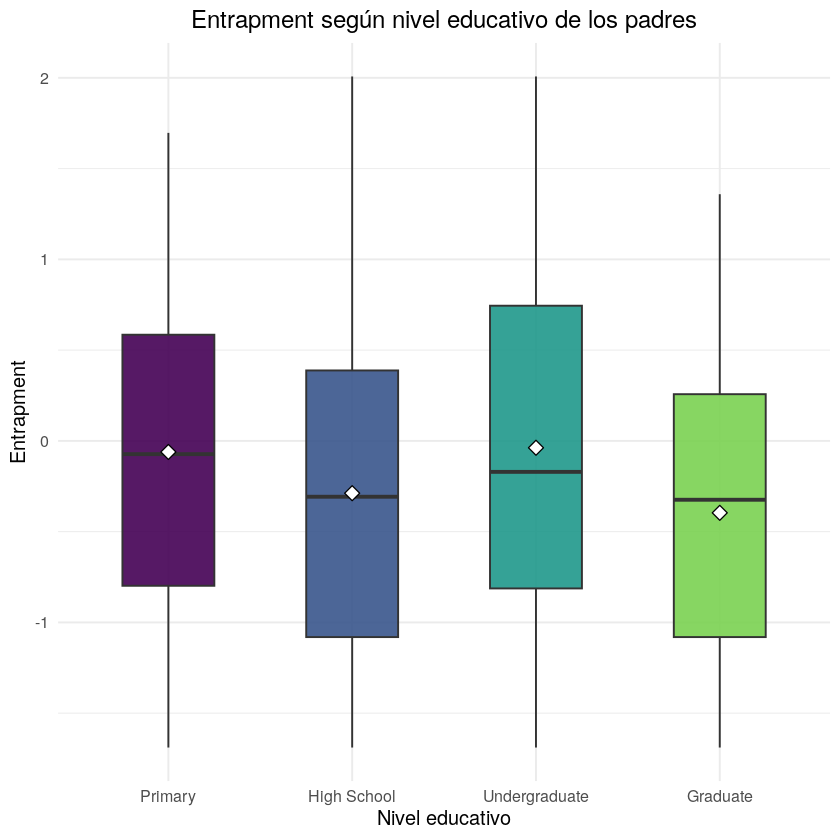

In [308]:
boxplot_cov(df_cov, "Education", "Entrapment según nivel educativo de los padres", "Nivel educativo")

Los estudiantes cuyos padres tienen educación primaria o universitaria muestran valores algo más altos de entrapment (medias cercanas a -0.05) que quienes tienen padres con secundaria o posgrado (alrededor de -0.3 y -0.4), sin un patrón ordenado según el nivel educativo.

In [309]:
tabla_grupos(df_cov, "Education", "Nivel educativo de los padres vs. entrapment")

<div id="hesscrswfz" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#hesscrswfz table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#hesscrswfz thead, #hesscrswfz tbody, #hesscrswfz tfoot, #hesscrswfz tr, #hesscrswfz td, #hesscrswfz th {
  border-style: none;
}

#hesscrswfz p {
  margin: 0;
  padding: 0;
}

#hesscrswfz .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#hesscrswfz .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#hesscrswfz .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#hesscrswfz .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#hesscrswfz .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#hesscrswfz .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#hesscrswfz .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#hesscrswfz .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#hesscrswfz .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#hesscrswfz .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#hesscrswfz .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#hesscrswfz .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#hesscrswfz .gt_spanner_row {
  border-bottom-style: hidden;
}

#hesscrswfz .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

ninguna prueba alcanza significancia: ni el ANOVA de Welch (p = .066) ni Kruskal-Wallis (p = .089), con un tamaño del efecto pequeño (cerca del 1% de la variación).

## *Asociación entre covariables categóricas*

Hasta aquí las covariables se cruzaron con el género y con el *entrapment*, pero no entre sí. Su estructura interna importa por dos razones: si dos covariables miden en parte lo mismo, incluirlas juntas en el modelo aporta información redundante, y si una está confundida con otra, el efecto que se le atribuya a una puede pertenecer a la otra. Se prueban los 10 pares posibles entre municipio, grado, nivel socioeconómico, etnia y nivel educativo de los padres con el mismo criterio de la tabla por género ($\chi^2$, con simulación de Monte Carlo cuando alguna frecuencia esperada es menor que 5) y se reporta la V de Cramér como tamaño del efecto. Cada prueba usa los casos con dato en ambas variables, y los valores p se ajustan con Holm por tratarse de una familia de 10 contrastes.

In [312]:
# Asociación entre las covariables categóricas (todos los pares).
# Mismo criterio de la tabla por género: Monte Carlo si alguna esperada es < 5.
set.seed(2026)

niveles_cat <- c(list(Gender = c("Female", "Male")), niveles_gen)
vars_cat <- names(niveles_cat)

factor_cat <- function(v) {
  x <- as.character(df[[v]])
  x[is.na(x) | x == ""] <- NA
  factor(x, levels = niveles_cat[[v]])
}

prueba_cat <- function(va, vb) {
  d <- tibble(a = factor_cat(va), b = factor_cat(vb)) %>% drop_na()
  tab <- table(d$a, d$b)

  mc <- any(suppressWarnings(chisq.test(tab)$expected) < 5)
  ji <- suppressWarnings(chisq.test(tab, simulate.p.value = mc, B = 10000))
  V  <- cramers_v(tab, adjust = FALSE)

  tibble(v1 = va, v2 = vb, n = nrow(d), Excluidos = nrow(df) - nrow(d),
         Prueba = if (mc) "χ² (Monte Carlo)" else "χ²",
         p = ji$p.value, V = V$Cramers_v)
}

# Los 15 pares (incluido género, para el mapa de calor); las 10 pruebas nuevas
# son las que no involucran a Gender.
res_todos <- map_dfr(combn(vars_cat, 2, simplify = FALSE), ~ prueba_cat(.x[1], .x[2]))

res_cov <- res_todos %>%
  filter(v1 != "Gender", v2 != "Gender") %>%
  mutate(p_holm = p.adjust(p, method = "holm")) %>%
  arrange(desc(V))

res_cov %>%
  gt() %>%
  fmt_number(V, decimals = 3) %>%
  fmt(columns = c(p, p_holm), fns = fmt_p) %>%
  cols_label(v1 = "Variable 1", v2 = "Variable 2", p_holm = "p (Holm)",
             Excluidos = "Missing (excluidos)", V = "V de Cramér") %>%
  tab_header(title = "Asociación entre covariables categóricas",
             subtitle = "10 pares; p ajustado por Holm dentro de esta familia de pruebas") %>%
  tab_source_note("Cada prueba usa solo los casos con dato en ambas variables, por lo que el n varía entre pares.")

"Cada prueba usa solo los casos con dato en ambas variables, por lo que el n varía entre pares."


Ninguna asociación es fuerte: la V de Cramér más alta es 0.215 y todas las demás quedan por debajo de 0.17, magnitudes que indican dependencias leves y no redundancia entre variables. Seis de los diez pares sobreviven a la corrección de Holm: nivel socioeconómico con nivel educativo de los padres (V = 0.215), municipio con etnia (0.169), municipio con grado (0.160), grado con nivel educativo (0.120), municipio con nivel educativo (0.113) y grado con nivel socioeconómico (0.111). Grado con etnia queda en zona ambigua (p = .024 sin ajustar, .096 tras Holm) y tres pares no muestran asociación alguna: municipio con nivel socioeconómico (p = .373), nivel socioeconómico con etnia (p = .456) y etnia con nivel educativo (p = .687).

Conviene leer los valores p con cautela: con n cercano a 600 en cada prueba, una V de 0.11 ya alcanza significancia, de modo que lo informativo es la magnitud y no el hecho de que el contraste sea significativo. El n varía entre 580 y 667 según los faltantes del par, y el caso extremo es nivel socioeconómico con etnia, que pierde 100 casos (14.7% de la muestra) al exigir dato en ambas variables.

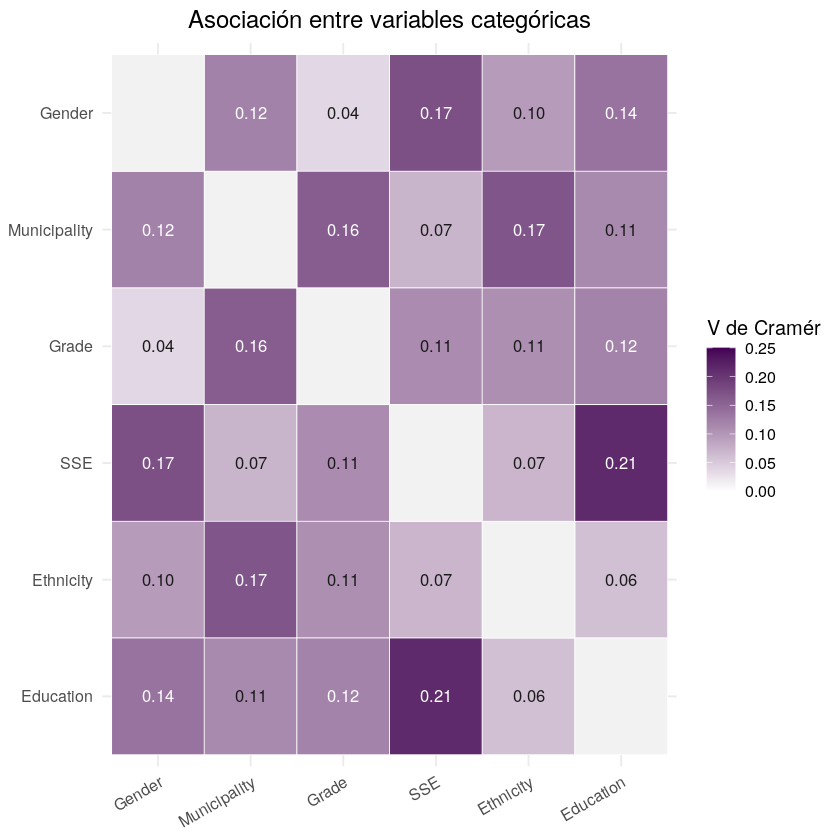

In [313]:
# Mapa de calor de la V de Cramér (incluye género como referencia).
v_largo <- res_todos %>% select(v1, v2, V)

v_mat <- bind_rows(
  v_largo,
  v_largo %>% select(v1 = v2, v2 = v1, V),
  tibble(v1 = vars_cat, v2 = vars_cat, V = NA_real_)
) %>%
  mutate(v1 = factor(v1, levels = vars_cat),
         v2 = factor(v2, levels = rev(vars_cat)))

ggplot(v_mat, aes(x = v1, y = v2, fill = V)) +
  geom_tile(color = "white") +
  geom_text(aes(label = ifelse(is.na(V), "", sprintf("%.2f", V)),
                color = !is.na(V) & V > 0.12),
            size = 3.5, show.legend = FALSE) +
  scale_fill_gradient(low = "white", high = col_morado, limits = c(0, 0.25),
                      na.value = "grey95", name = "V de Cramér") +
  scale_color_manual(values = c(`TRUE` = "white", `FALSE` = "grey10"), guide = "none") +
  labs(title = "Asociación entre variables categóricas", x = NULL, y = NULL) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

El mapa resume el panorama e incluye el género como referencia: esa fila reproduce exactamente los resultados de la tabla por género de la sección anterior (0.121 con municipio, 0.038 con grado, 0.175 con nivel socioeconómico, 0.096 con etnia y 0.137 con nivel educativo), lo que sirve de verificación cruzada. Las dos celdas más oscuras son nivel socioeconómico con nivel educativo (0.21) y género con nivel socioeconómico (0.17), y la más clara es género con grado (0.04), es decir, mujeres y hombres están repartidos de forma prácticamente idéntica entre los tres cursos.

La escala llega apenas a 0.25 y ninguna celda se acerca a los valores que suelen considerarse problemáticos (V por encima de 0.5): la matriz completa describe un conjunto de variables con dependencias débiles. Hay que tener en cuenta que la V solo mide intensidad, no dirección ni qué categorías generan la asociación, y para eso hacen falta las tablas de contingencia que siguen.

In [314]:
# Tabla de contingencia con n y porcentaje por fila, más la prueba del par.
tabla_contingencia <- function(va, vb) {
  d <- tibble(a = factor_cat(va), b = factor_cat(vb)) %>% drop_na()
  tab <- table(d$a, d$b)
  pct <- prop.table(tab, margin = 1) * 100
  est <- res_todos %>% filter((v1 == va & v2 == vb) | (v1 == vb & v2 == va))

  cuerpo <- as.data.frame.matrix(tab)
  cuerpo[] <- sprintf("%d (%.1f%%)", tab, pct)

  cuerpo %>%
    rownames_to_column(va) %>%
    mutate(Total = as.integer(rowSums(tab))) %>%
    gt() %>%
    tab_spanner(label = vb, columns = all_of(colnames(tab))) %>%
    tab_header(title = sprintf("%s × %s", va, vb), subtitle = "n (% por fila)") %>%
    tab_source_note(sprintf("n = %d · %s: p = %s · V de Cramér = %.3f",
                            est$n, est$Prueba, fmt_p(est$p), est$V))
}

# El municipio es la unidad de agrupamiento del diseño: se cruza con el resto.
pares_municipio <- list(c("Municipality", "Grade"), c("Municipality", "SSE"),
                        c("Municipality", "Ethnicity"), c("Municipality", "Education"))

walk(pares_municipio, ~ IRdisplay::display_html(as_raw_html(tabla_contingencia(.x[1], .x[2]))))

n = 667 · χ²: p = < .001 · V de Cramér = 0.160


n = 611 · χ² (Monte Carlo): p = 0.373 · V de Cramér = 0.072


n = 624 · χ² (Monte Carlo): p = < .001 · V de Cramér = 0.169


n = 637 · χ² (Monte Carlo): p = 0.006 · V de Cramér = 0.113


El municipio es la unidad de agrupamiento del diseño, y las tablas muestran que no es intercambiable entre variables. El cruce con el grado (V = 0.160) revela el problema más claro: Suan es casi enteramente 11.º grado (16 de 18 estudiantes, 88.9%), con un solo caso en 9.º y otro en 10.º, mientras que Santo Tomás concentra más 9.º (38.4%) y menos 11.º (26.3%). En Suan, municipio y grado están confundidos: cualquier diferencia que se atribuya a ese municipio podría corresponder al grado, y viceversa.

El cruce con el nivel socioeconómico es el único del bloque sin asociación (V = 0.072, p = .373): los cuatro municipios son mayoritariamente de estrato bajo, entre 75.8% y 83.3%, de modo que el municipio no aporta variación socioeconómica y no puede usarse como su sustituto. Sí discrimina en composición étnica (V = 0.169), donde Santo Tomás es mitad mestizo (50.0%), Polo Nuevo reparte mestizos y caucásicos casi por igual (36.3% y 36.9%), Puerto Colombia es el más heterogéneo (26.8% en el grupo Other) y Suan concentra afrodescendientes (50.0%, 9 de 18). Y discrimina en nivel educativo de los padres (V = 0.113): Santo Tomás reúne a los padres con más estudios (17.9% universitario y 12.7% posgrado, frente a 9.6% y 6.9% en Polo Nuevo), mientras que en Suan el 94.4% llegó solo a secundaria.

Conviene recordar que Suan aporta apenas 18 casos con dato, así que cada estudiante mueve sus porcentajes más de cinco puntos; esa es justamente la razón por la que varios de estos contrastes se resolvieron por Monte Carlo.

In [315]:
# Pares restantes entre variables de composición individual.
pares_restantes <- list(c("Grade", "SSE"), c("Grade", "Ethnicity"), c("Grade", "Education"),
                        c("SSE", "Ethnicity"), c("SSE", "Education"),
                        c("Ethnicity", "Education"))

walk(pares_restantes, ~ IRdisplay::display_html(as_raw_html(tabla_contingencia(.x[1], .x[2]))))

n = 606 · χ² (Monte Carlo): p = 0.003 · V de Cramér = 0.111


n = 618 · χ²: p = 0.024 · V de Cramér = 0.108


n = 631 · χ²: p = 0.006 · V de Cramér = 0.120


n = 580 · χ² (Monte Carlo): p = 0.456 · V de Cramér = 0.070


n = 587 · χ² (Monte Carlo): p = < .001 · V de Cramér = 0.215


n = 596 · χ²: p = 0.687 · V de Cramér = 0.060


El nivel socioeconómico y el nivel educativo de los padres forman la asociación más fuerte de todo el conjunto (V = 0.215), y la tabla muestra por qué: entre los estudiantes de estrato bajo, el 76.4% de los padres llegó solo a secundaria y apenas el 5.7% a posgrado, mientras que en estrato medio la secundaria baja al 49.1% y suben el nivel universitario (26.4%) y el posgrado (18.2%). Las dos variables capturan en parte la misma información, lo cual es esperable; con V = 0.215 pueden incluirse juntas sin colinealidad problemática, pero su aporte no es independiente.

El grado se relaciona con ambas: en 11.º hay más estrato bajo (87.2%) y ningún caso de estrato alto, mientras que 10.º concentra el estrato medio (23.7%), y la proporción de padres con posgrado cae de 13.2% en 9.º a 3.2% en 11.º. El grado, entonces, no es solo un marcador de edad: recoge también diferencias de composición socioeconómica entre cursos, algo a tener en cuenta si se lo incluye como covariable. Su cruce con la etnia apunta en la misma dirección (el grupo Other pasa de 16.1% en 9.º a 7.8% en 11.º), pero queda como tendencia sin respaldo tras la corrección de Holm.

Los dos pares restantes no muestran asociación: la composición étnica es prácticamente idéntica en los distintos estratos (p = .456) y en los distintos niveles educativos de los padres (p = .687), con diferencias de pocos puntos porcentuales entre filas. En el cruce con el estrato, además, la fila `High` tiene solo 7 estudiantes y no es informativa por sí sola.

En conjunto, estas dependencias no obligan a descartar ninguna covariable por redundancia, pero sí matizan la decisión sobre cuáles incluir en los modelos de moderación: nivel socioeconómico y nivel educativo de los padres se solapan, el municipio está parcialmente confundido con el grado a través de Suan y no sustituye al estrato, y la etnia es independiente del resto. Como ninguna de estas covariables se asoció con el *entrapment* en el bivariado, el riesgo para el efecto principal es bajo; la precaución es relevante sobre todo al ajustar la interacción Apoyo × Género por varias covariables a la vez.

# *Conclusión*

El entrapment se asocia de forma clara con el género y con el apoyo social. Las mujeres presentan más entrapment que los hombres, con un efecto moderado que se sostiene con las pruebas paramétrica y no paramétrica. Las tres dimensiones del apoyo social se relacionan negativamente con el entrapment (más apoyo, menos entrapment): la asociación es moderada para la familia y débil para amigos y otras personas significativas, es sólida frente al efecto piso y es aproximadamente lineal. Las mujeres perciben además menos apoyo familiar que los hombres, lo que es coherente con su mayor entrapment.

Al separar por género, la asociación entre apoyo y entrapment es algo más fuerte en las mujeres en las tres dimensiones, pero solo la diferencia en Family alcanza significancia y no se sostendría con una corrección por comparaciones múltiples, así que hay una tendencia sin evidencia suficiente de moderación. Esa pregunta debe resolverse con el término de interacción en los modelos de regresión.

Ninguna covariable (edad, grado, municipio, etnia, nivel socioeconómico y nivel educativo de los padres) se asocia de forma apreciable con el entrapment. Su inclusión en los modelos debe decidirse por criterio teórico y de diseño (edad, nivel socioeconómico y municipio), no por su significancia bivariada: el grado no debería entrar junto con la edad, y la etnia y el nivel educativo de los padres pueden reservarse para análisis de sensibilidad por su proporción de datos faltantes.

Estos resultados son asociaciones descriptivas en datos transversales, no efectos causales. Los siguientes pasos son estimar el término de interacción Apoyo × Género en modelos de regresión ajustados por covariables, tratar los datos faltantes con imputación  y revisar la multicolinealidad entre las tres dimensiones del apoyo (r entre 0.43 y 0.56), teniendo en cuenta el efecto piso del entrapment.